In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [2]:
file_paths = sorted(glob.glob("../outputs/gender_output_2025-10-11 13:17:30.574798_ContrastiveLoss_gru_logreg/out_*.csv"))
all_dfs = []

for path in file_paths:
    df = pd.read_csv(path)
    df["sample_fraction"] = float(path.split("_")[-1].replace(".csv", ""))
    all_dfs.append(df)

# Объединяем в один DataFrame
df_all = pd.concat(all_dfs, ignore_index=True)

In [7]:
len(df_all.dropna(axis=1))

2940

In [4]:
print(df_all['roc_auc'])

0       0.7166
1       0.7166
2       0.7327
3       0.7327
4       0.7341
         ...  
2935    0.6841
2936    0.6897
2937    0.6897
2938    0.6860
2939    0.6860
Name: roc_auc, Length: 2940, dtype: float64


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()

scaled = scaler.fit_transform(df_all[["metric_ripser_sum_H0", "metric_ripser_sum_H1"]])
weighted_sum = scaled[:, 0] - scaled[:, 1]
df_all['ripser_weighted'] = weighted_sum

In [54]:
#combinations
metric_columns = [col for col in df_all.columns if (("metric_" in col) and ("train" in col))] \
+ [ 'recall_topk']

In [ ]:
#combinations
metric_columns = [col for col in df_all.columns if ("metric_" in col)] \
+ [ 'recall_topk']
all_metric_columns = []
for metric1 in metric_columns:
    for metric2 in metric_columns:
        scaler = MinMaxScaler()
        scaled = scaler.fit_transform(df_all[[metric1, metric2]])
        weighted_sum = np.mean(scaled, axis=1)
        all_metric_columns.append(metric1 + "_" + metric2 + '_weighted')
        all_metric_columns.append(metric1 + "_" + metric2 + '_prod')
        df_all[metric1 + "_" + metric2 + '_weighted'] = weighted_sum
        df_all[metric1 + "_" + metric2 + '_prod'] = scaled[:,0] * scaled[:,1]

all_metric_columns += metric_columns

In [8]:
df_all = df_all.set_index('checkpoint')

In [55]:
import numpy as np
corr_records = []

# Вычисляем корреляцию с accuracy для каждой метрики при каждом sample_fraction
for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.][metric].corr(
                sub['roc_auc'], method='spearman'))
        curr = ~np.isnan(sub[metric].values)
        if sub[metric].nunique() > 1:  # нужно хотя бы 2 уникальных значения для корреляции
            corr = sub[metric][curr].corr(sub['roc_auc'][curr])
            corr_records.append({
                "sample_fraction": frac,
                "metric": metric,
                "correlation": corr
            })

/home/dpetrovitch/venv/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


/tmp/ipykernel_1470740/3475833712.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


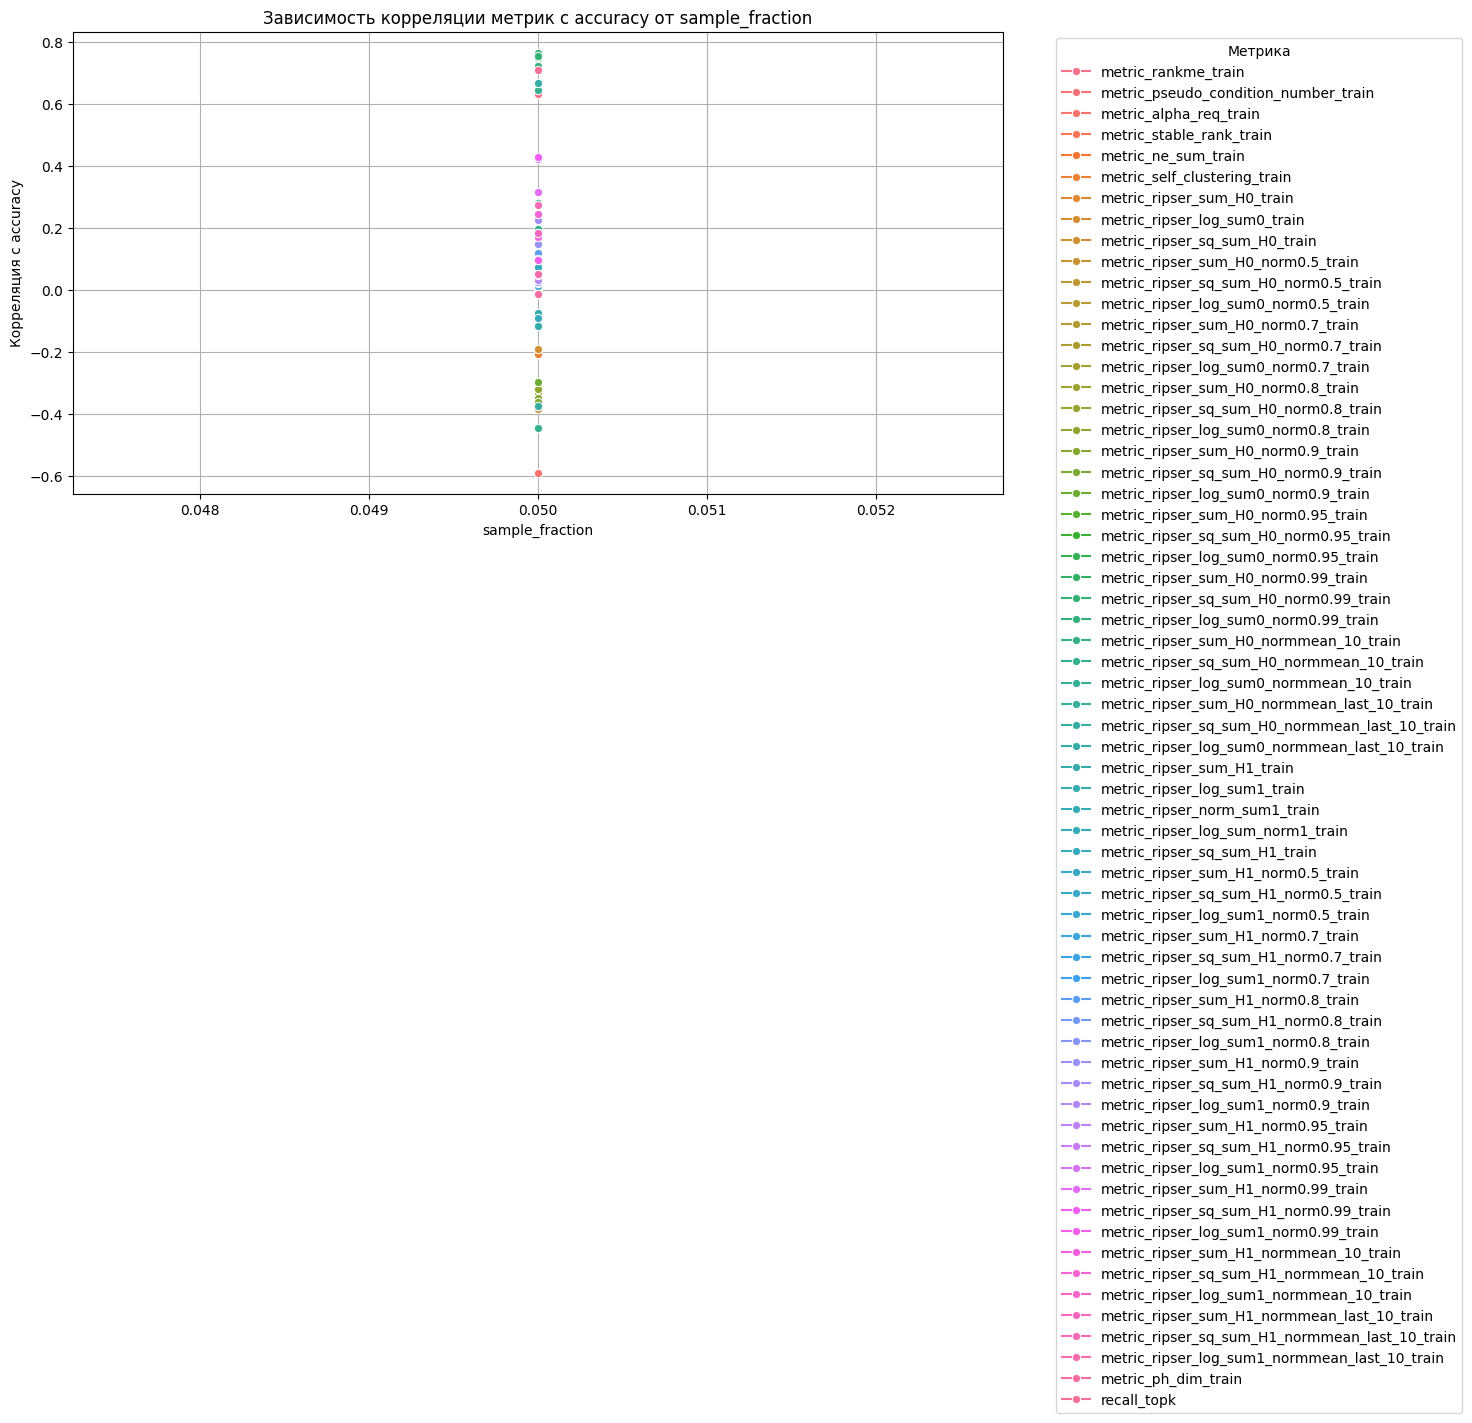

In [56]:
corr_df = pd.DataFrame(corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [57]:
print(corr_df)

    sample_fraction                                          metric  \
0              0.05                             metric_rankme_train   
1              0.05            metric_pseudo_condition_number_train   
2              0.05                          metric_alpha_req_train   
3              0.05                        metric_stable_rank_train   
4              0.05                             metric_ne_sum_train   
..              ...                                             ...   
59             0.05     metric_ripser_sum_H1_normmean_last_10_train   
60             0.05  metric_ripser_sq_sum_H1_normmean_last_10_train   
61             0.05   metric_ripser_log_sum1_normmean_last_10_train   
62             0.05                             metric_ph_dim_train   
63             0.05                                     recall_topk   

    correlation  
0      0.629397  
1      0.179340  
2     -0.588946  
3     -0.007971  
4      0.754396  
..          ...  
59     0.182172  
60 

In [58]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ripser_sum_H0_norm0.99_train': 0.764702883256389,
 'metric_ripser_sum_H0_norm0.95_train': 0.7576382734908779,
 'metric_ne_sum_train': 0.7543960677906155,
 'metric_ripser_sq_sum_H0_norm0.99_train': 0.7531632404356989,
 'metric_ripser_sq_sum_H0_norm0.95_train': 0.7467635032634784,
 'metric_ripser_log_sum0_norm0.95_train': 0.7235769300967503,
 'metric_ripser_log_sum0_norm0.99_train': 0.7205729831610194,
 'recall_topk': 0.7077065088501402,
 'metric_ripser_log_sum0_normmean_last_10_train': 0.6654525355792841,
 'metric_ripser_log_sum0_normmean_10_train': 0.6428618842971919,
 'metric_rankme_train': 0.6293974088100094,
 'metric_ripser_sq_sum_H1_norm0.99_train': 0.4265108717126524,
 'metric_ripser_sq_sum_H1_norm0.95_train': 0.42244199651036696,
 'metric_ripser_sum_H1_norm0.99_train': 0.3159182978431136,
 'metric_ripser_sum_H1_norm0.95_train': 0.31067717280298646,
 'metric_ripser_sum_H0_normmean_last_10_train': 0.27832302199347253,
 'metric_ripser_log_sum0_train': 0.27809263923099675,
 

In [ ]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

In [ ]:
mean_corr = corr_df[corr_df['sample_fraction'] < 0.5].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

# Overall Spearmann Corr

In [59]:
from scipy.stats import spearmanr


spear_corr_records = []

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        # sign = np.sign(df_all[df_all['sample_fraction'] > 0.][metric].corr(
        #     sub['roc_auc'], method='spearman'))
        #print(frac, metric, sub[metric].dropna())
        curr = ~np.isnan(sub[metric].values)
        #print(curr)
        if sub[metric].nunique() > 1 and sub['accuracy'].nunique() > 1:
            corr, _ = spearmanr(sub[metric].values[curr], sub['roc_auc'].values[curr])
            spear_corr_records.append({
                "sample_fraction": frac,
                "metric": metric,
                "correlation": corr
            })
            


/tmp/ipykernel_1470740/1552398705.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


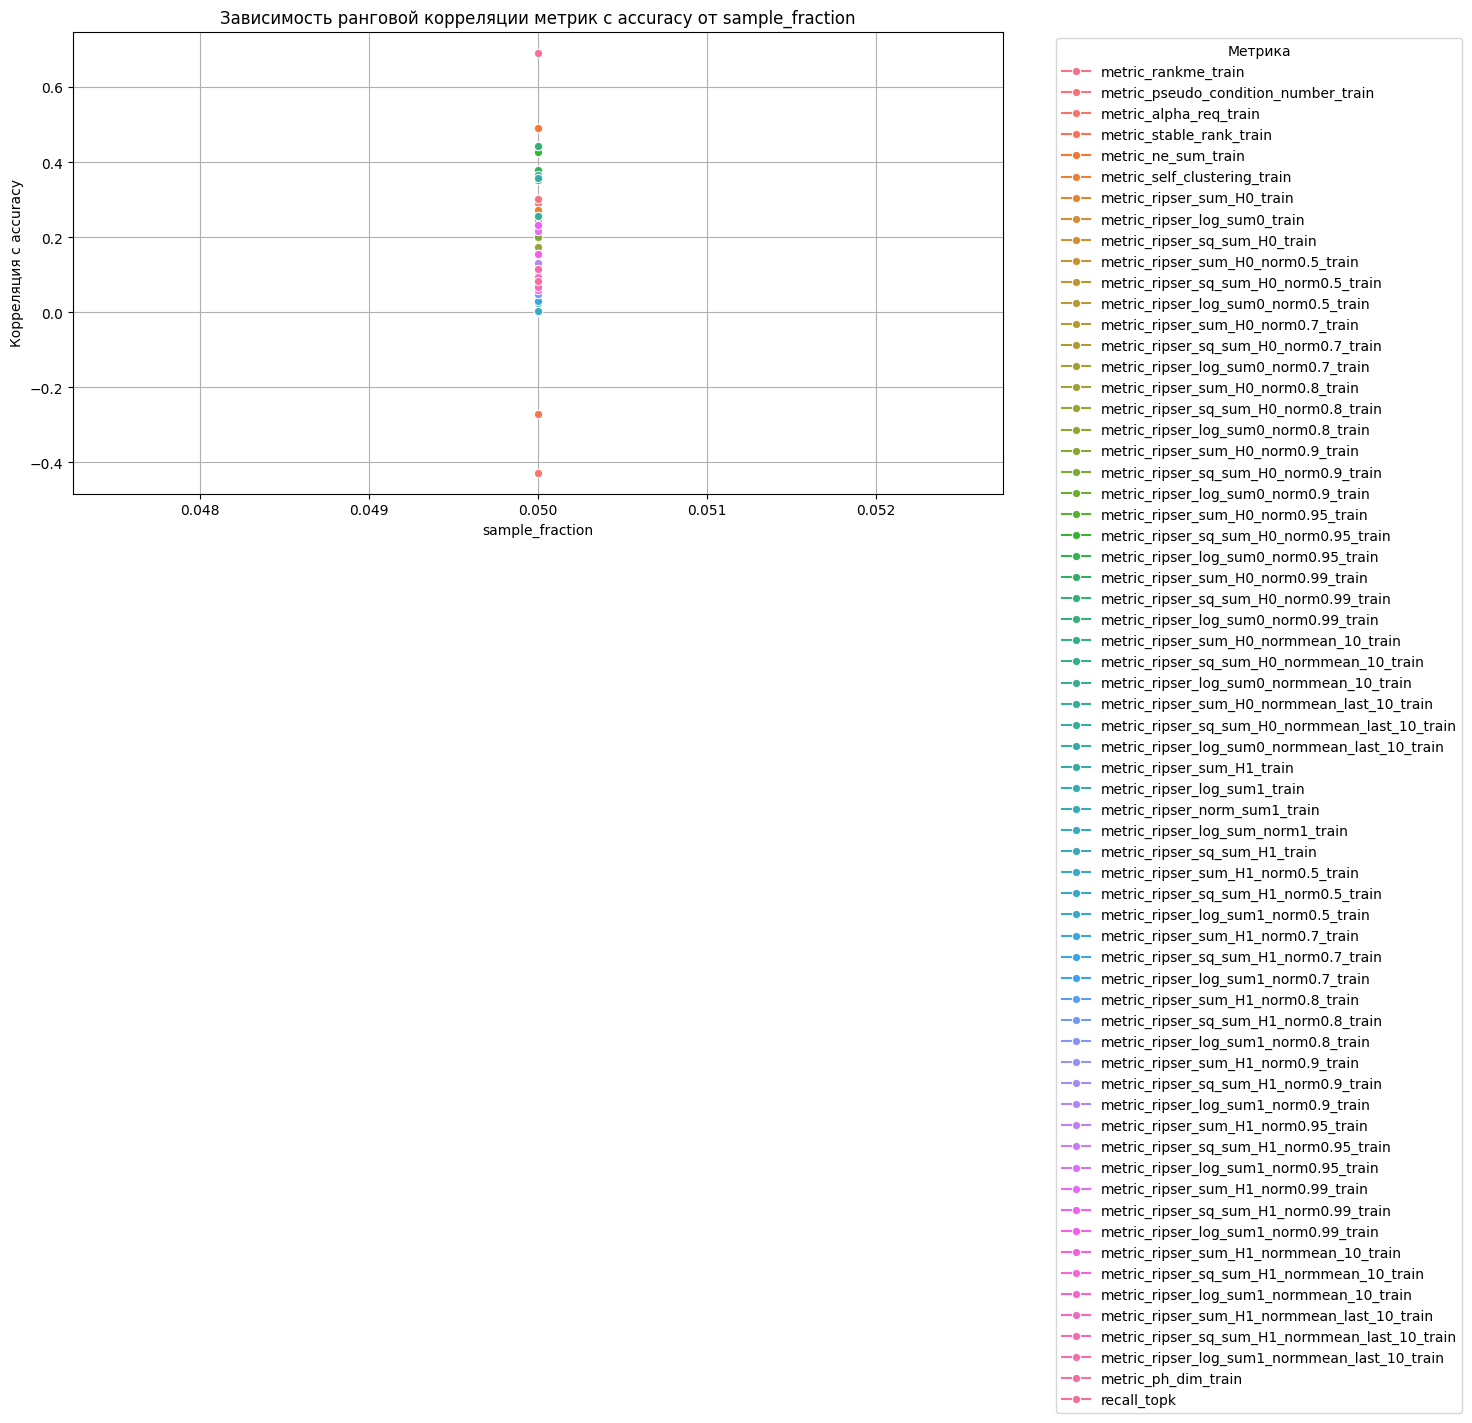

In [60]:
spear_corr_df = pd.DataFrame(spear_corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=spear_corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [61]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'recall_topk': 0.6923532041049931,
 'metric_ne_sum_train': 0.4904186843847856,
 'metric_ripser_sq_sum_H0_norm0.99_train': 0.44391260043650327,
 'metric_ripser_sum_H0_norm0.99_train': 0.44323795839773755,
 'metric_ripser_sum_H0_norm0.95_train': 0.4269065123570008,
 'metric_ripser_sq_sum_H0_norm0.95_train': 0.4260240955743539,
 'metric_ripser_log_sum0_norm0.95_train': 0.3795640365657407,
 'metric_ripser_log_sum0_normmean_10_train': 0.36494073966951807,
 'metric_ripser_log_sum0_normmean_last_10_train': 0.3570871451674618,
 'metric_ripser_log_sum0_norm0.99_train': 0.35235255507244395,
 'metric_pseudo_condition_number_train': 0.3020728786858553,
 'metric_rankme_train': 0.2911340924612558,
 'metric_self_clustering_train': 0.27266181736292056,
 'metric_ripser_sum_H0_normmean_last_10_train': 0.255866512606944,
 'metric_ripser_sum_H0_normmean_10_train': 0.2555638695056388,
 'metric_ripser_log_sum0_train': 0.24756687458621449,
 'metric_ripser_log_sum0_norm0.5_train': 0.24508352068310152,
 'metr

In [62]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.0].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'recall_topk': 0.6923532041049931,
 'metric_ne_sum_train': 0.4904186843847856,
 'metric_ripser_sq_sum_H0_norm0.99_train': 0.44391260043650327,
 'metric_ripser_sum_H0_norm0.99_train': 0.44323795839773755,
 'metric_ripser_sum_H0_norm0.95_train': 0.4269065123570008,
 'metric_ripser_sq_sum_H0_norm0.95_train': 0.4260240955743539,
 'metric_ripser_log_sum0_norm0.95_train': 0.3795640365657407,
 'metric_ripser_log_sum0_normmean_10_train': 0.36494073966951807,
 'metric_ripser_log_sum0_normmean_last_10_train': 0.3570871451674618,
 'metric_ripser_log_sum0_norm0.99_train': 0.35235255507244395,
 'metric_pseudo_condition_number_train': 0.3020728786858553,
 'metric_rankme_train': 0.2911340924612558,
 'metric_self_clustering_train': 0.27266181736292056,
 'metric_ripser_sum_H0_normmean_last_10_train': 0.255866512606944,
 'metric_ripser_sum_H0_normmean_10_train': 0.2555638695056388,
 'metric_ripser_log_sum0_train': 0.24756687458621449,
 'metric_ripser_log_sum0_norm0.5_train': 0.24508352068310152,
 'metr

In [ ]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] < 0.4].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

# Correlation for best checkpoint choice

In [63]:
from scipy.stats import spearmanr


spear_corr_records = []
df_all['checkpoint'] = df_all.index.values
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
            sub['roc_auc'], method='spearman'))
        for check, check_data in sub.groupby('runs'):   
            curr = ~np.isnan(check_data[metric].values)
            if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                corr, _ = spearmanr(check_data[metric].values[curr], check_data['roc_auc'].values[curr])
                spear_corr_records.append({
                    "sample_fraction": frac,
                    "metric": metric,
                    "correlation": corr
                })
            


/tmp/ipykernel_1470740/1552398705.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


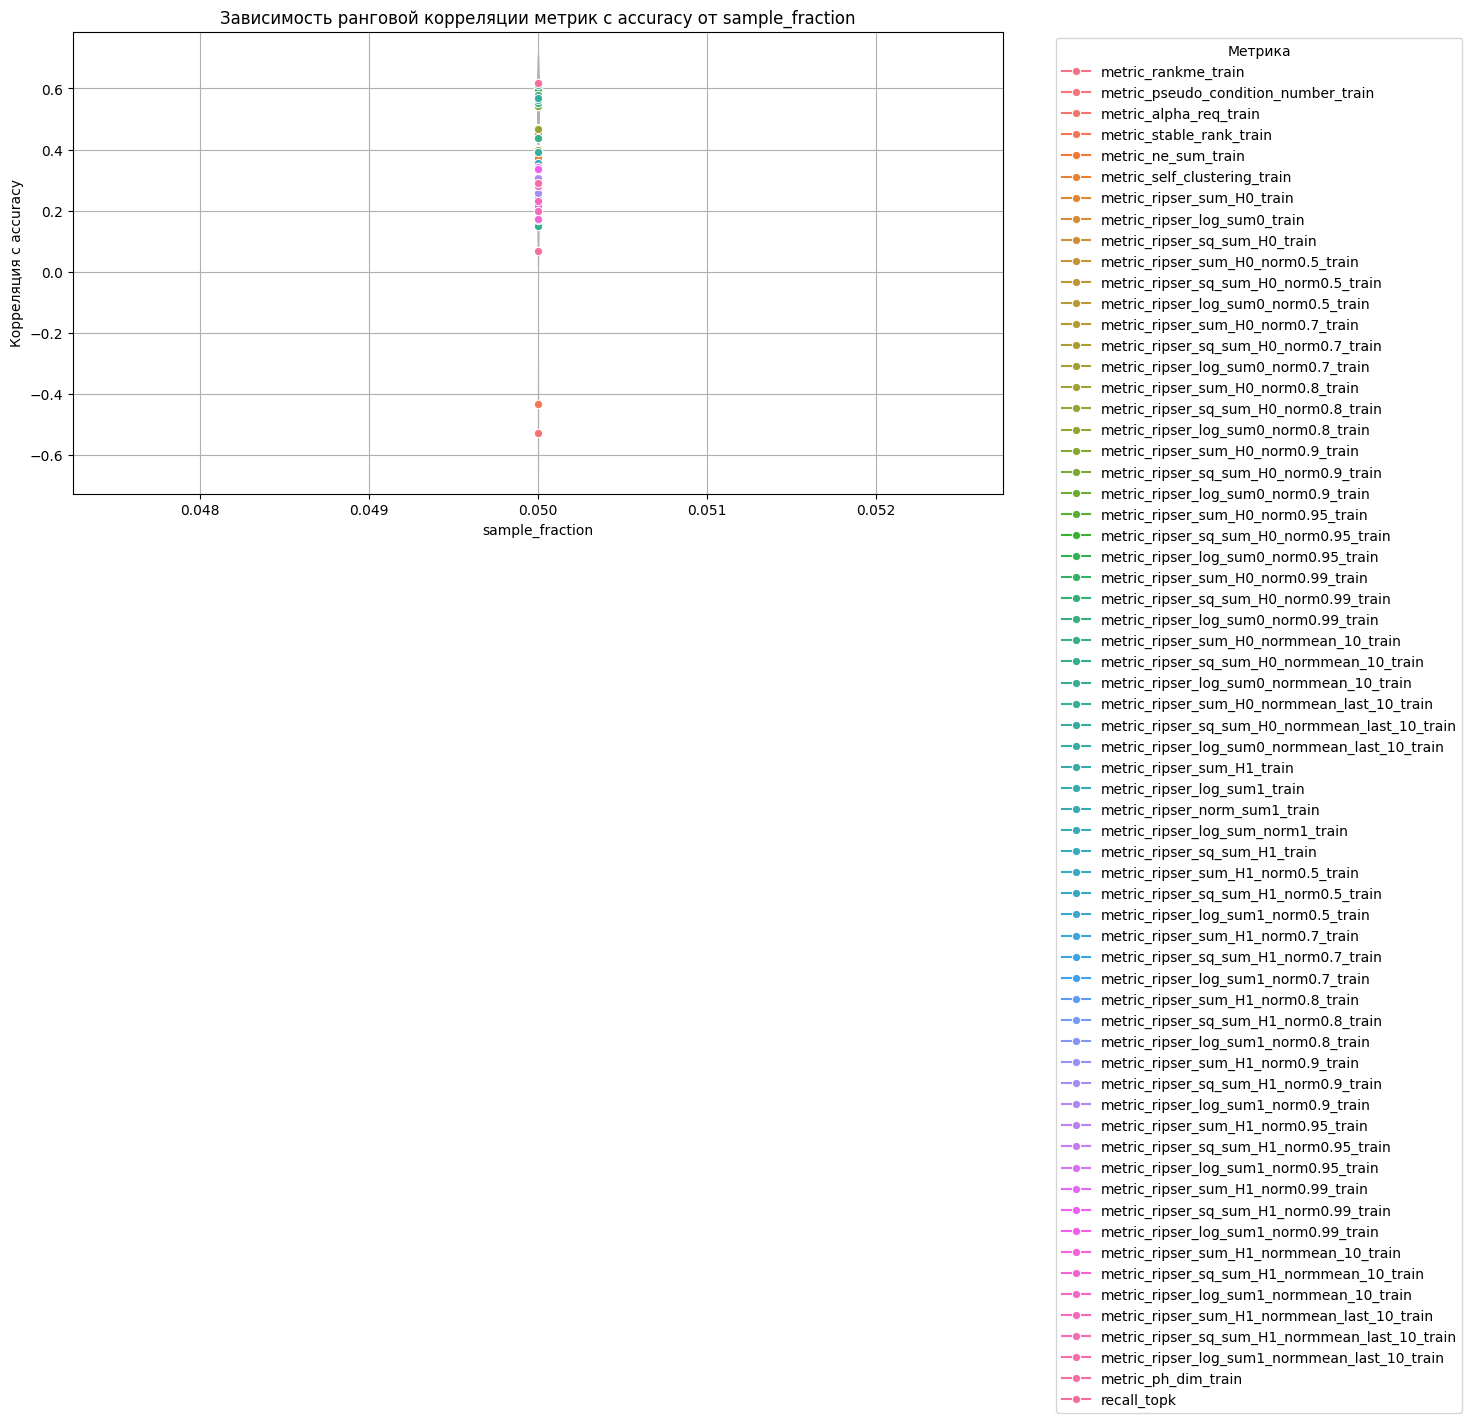

In [64]:
spear_corr_df = pd.DataFrame(spear_corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=spear_corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [65]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{}

In [66]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.0].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ripser_log_sum0_norm0.9_train': 0.6190826115085102,
 'recall_topk': 0.6173157977685201,
 'metric_ripser_log_sum0_normmean_last_10_train': 0.6126129454335416,
 'metric_ripser_log_sum0_norm0.7_train': 0.6116192445933343,
 'metric_ripser_log_sum0_norm0.8_train': 0.6071533280810844,
 'metric_ripser_log_sum0_norm0.95_train': 0.598484583284684,
 'metric_ripser_sum_H0_train': 0.5981830577626468,
 'metric_ripser_sum_H0_norm0.9_train': 0.5972242417668125,
 'metric_ripser_log_sum0_train': 0.5949888446761169,
 'metric_ripser_sq_sum_H0_train': 0.5857014324592645,
 'metric_ripser_sq_sum_H0_norm0.95_train': 0.5835798672975383,
 'metric_ripser_sum_H0_norm0.95_train': 0.5824574398938028,
 'metric_ripser_log_sum0_norm0.99_train': 0.577560059407045,
 'metric_ripser_sum_H0_normmean_last_10_train': 0.5685552114679862,
 'metric_ripser_sum_H0_norm0.8_train': 0.5651180387735403,
 'metric_ripser_log_sum0_normmean_10_train': 0.5632743860302342,
 'metric_ripser_sum_H0_norm0.99_train': 0.554392980903255

In [ ]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] < 0.5].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

# Linear correlation of epoch choice

In [67]:

corr_records = []
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
            sub['roc_auc'], method='spearman'))
        for check, check_data in sub.groupby('runs'): 
            curr = ~np.isnan(check_data[metric].values)
            if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                corr = check_data[metric][curr].corr(check_data['roc_auc'][curr])
                corr_records.append({
                    "sample_fraction": frac,
                    "metric": metric,
                    "correlation": corr
                })
     

/tmp/ipykernel_1470740/787648205.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


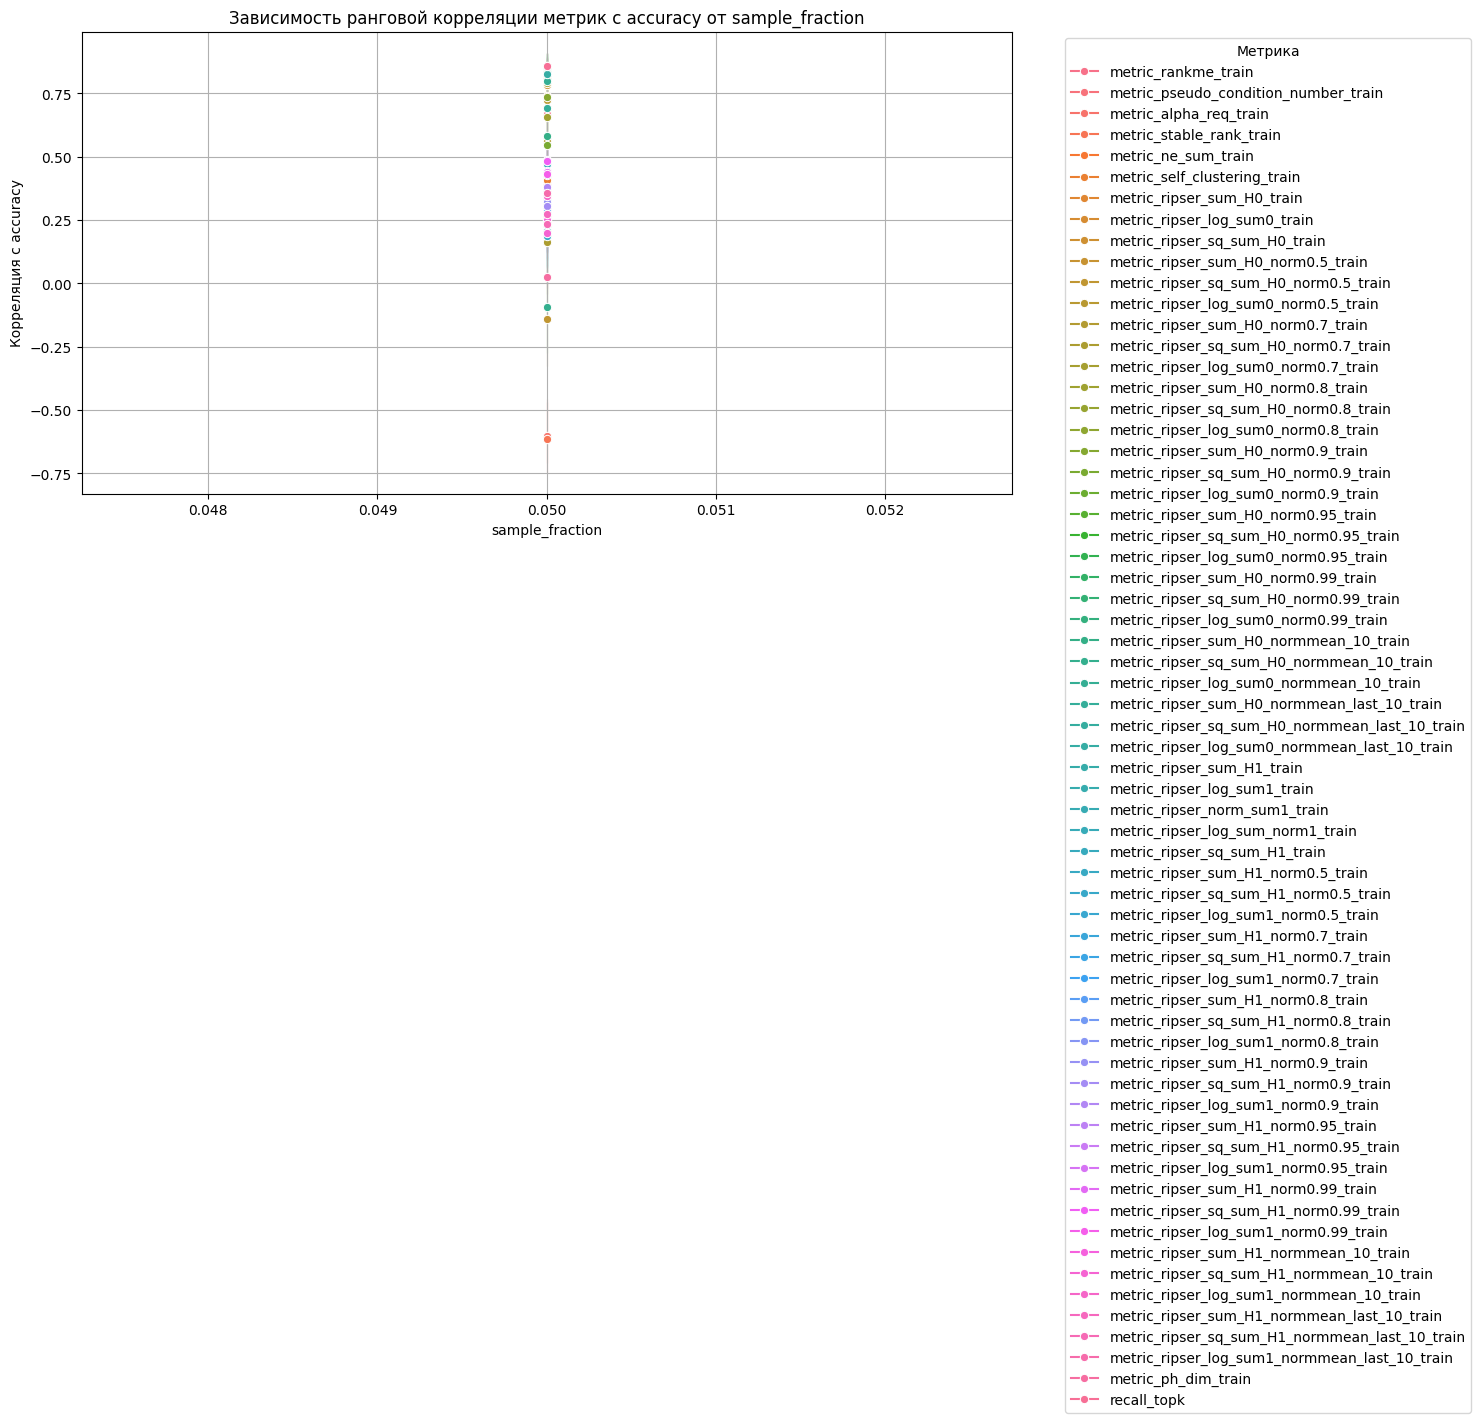

In [68]:
corr_df = pd.DataFrame(corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [ ]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

In [69]:
mean_corr = corr_df[corr_df['sample_fraction'] < 0.4].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ripser_log_sum0_norm0.95_train': 0.8575069366353435,
 'recall_topk': 0.8569666989649178,
 'metric_ripser_sum_H0_norm0.95_train': 0.8527142909483385,
 'metric_ripser_log_sum0_norm0.99_train': 0.8524996284943638,
 'metric_ripser_sq_sum_H0_norm0.95_train': 0.8505330703989308,
 'metric_ripser_sum_H0_norm0.99_train': 0.843081186529729,
 'metric_ripser_sq_sum_H0_norm0.99_train': 0.8371602410832958,
 'metric_ripser_log_sum0_norm0.9_train': 0.8301606017276671,
 'metric_ripser_log_sum0_normmean_last_10_train': 0.8276889800441901,
 'metric_ripser_log_sum0_train': 0.826184225439286,
 'metric_ripser_sum_H0_train': 0.8140742294410738,
 'metric_ripser_log_sum0_norm0.8_train': 0.8081855729220637,
 'metric_ripser_log_sum0_normmean_10_train': 0.7999615352240512,
 'metric_ripser_log_sum0_norm0.7_train': 0.788934754502386,
 'metric_ripser_sq_sum_H0_train': 0.784236211566928,
 'metric_ne_sum_train': 0.7405629200079665,
 'metric_ripser_sum_H0_norm0.9_train': 0.7356507761321447,
 'metric_ripser_log

# Score of best epoch

In [71]:
corr_records = []
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
            sub['roc_auc'], method='spearman'))
        for check, check_data in sub.groupby('runs'):
            curr = ~np.isnan(check_data[metric])
            if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                pick = check_data['roc_auc'].values[curr][
                    np.argmax(check_data[metric].values[curr])]
                corr_records.append({
                    "sample_fraction": frac,
                    "metric": metric,
                    "auc": pick
                })

/tmp/ipykernel_1470740/3876850653.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


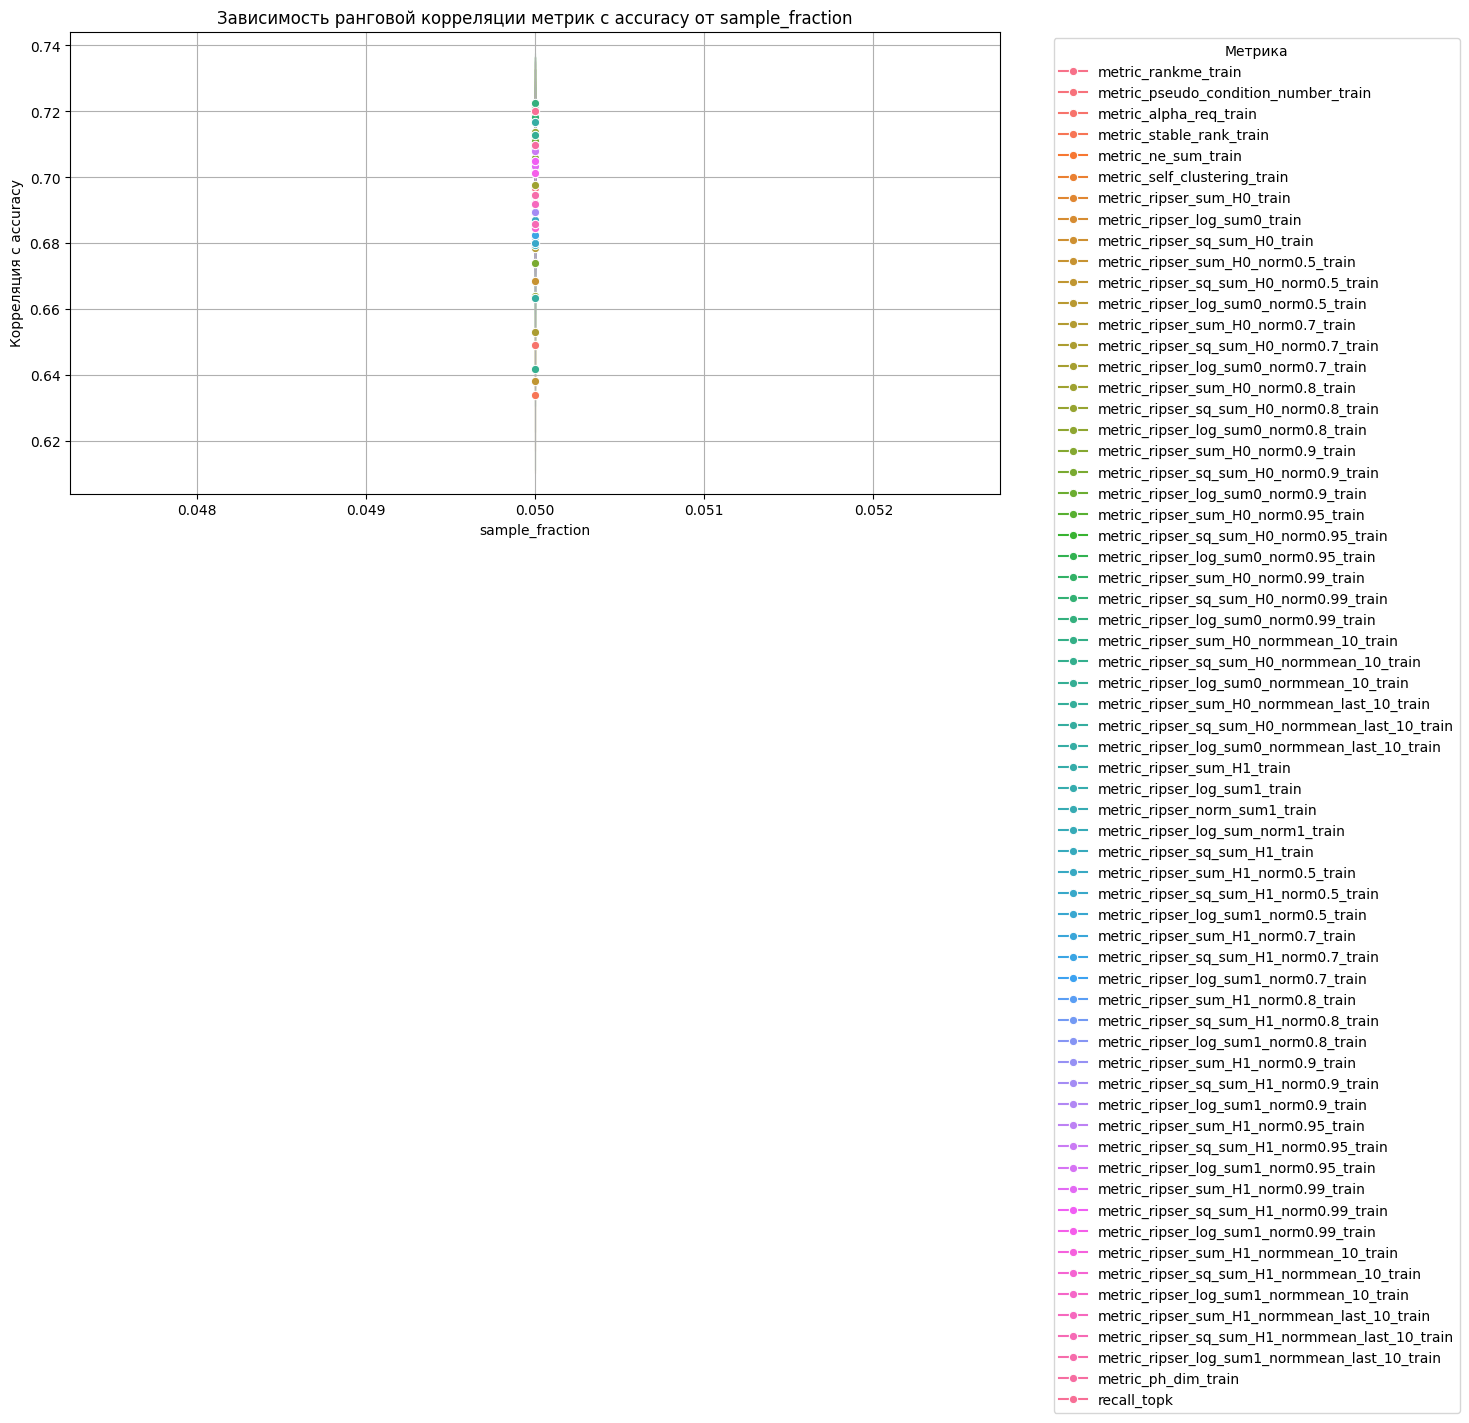

In [72]:
corr_df = pd.DataFrame(corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_df, x="sample_fraction", y="auc", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [73]:
corr_df = pd.DataFrame(corr_records)
mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["auc"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ripser_log_sum0_norm0.99_train': 0.7224411764705883,
 'metric_ripser_log_sum0_norm0.95_train': 0.7211323529411765,
 'metric_ripser_sum_H0_norm0.99_train': 0.7207264705882352,
 'metric_ripser_sum_H0_norm0.95_train': 0.7206411764705882,
 'recall_topk': 0.7201411764705883,
 'metric_ripser_log_sum0_train': 0.7190823529411764,
 'metric_ripser_sq_sum_H0_norm0.99_train': 0.7182647058823529,
 'metric_ripser_sq_sum_H0_norm0.95_train': 0.7182323529411764,
 'metric_ripser_sum_H0_train': 0.7179764705882353,
 'metric_rankme_train': 0.7175411764705882,
 'metric_ripser_sq_sum_H0_train': 0.7174176470588235,
 'metric_ripser_log_sum0_normmean_last_10_train': 0.7168617647058824,
 'metric_ripser_log_sum0_norm0.8_train': 0.7137529411764706,
 'metric_ne_sum_train': 0.7134058823529412,
 'metric_ripser_log_sum0_normmean_10_train': 0.7128735294117647,
 'metric_ripser_log_sum0_norm0.7_train': 0.7117352941176471,
 'metric_ripser_log_sum0_norm0.9_train': 0.7108705882352941,
 'metric_ph_dim_train': 0.7098

In [ ]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["auc"].mean().sort_values(ascending=False)
mean_corr.to_dict()

In [74]:
mean_corr = corr_df[corr_df['sample_fraction'] < 0.4].groupby("metric")["auc"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ripser_log_sum0_norm0.99_train': 0.7224411764705883,
 'metric_ripser_log_sum0_norm0.95_train': 0.7211323529411765,
 'metric_ripser_sum_H0_norm0.99_train': 0.7207264705882352,
 'metric_ripser_sum_H0_norm0.95_train': 0.7206411764705882,
 'recall_topk': 0.7201411764705883,
 'metric_ripser_log_sum0_train': 0.7190823529411764,
 'metric_ripser_sq_sum_H0_norm0.99_train': 0.7182647058823529,
 'metric_ripser_sq_sum_H0_norm0.95_train': 0.7182323529411764,
 'metric_ripser_sum_H0_train': 0.7179764705882353,
 'metric_rankme_train': 0.7175411764705882,
 'metric_ripser_sq_sum_H0_train': 0.7174176470588235,
 'metric_ripser_log_sum0_normmean_last_10_train': 0.7168617647058824,
 'metric_ripser_log_sum0_norm0.8_train': 0.7137529411764706,
 'metric_ne_sum_train': 0.7134058823529412,
 'metric_ripser_log_sum0_normmean_10_train': 0.7128735294117647,
 'metric_ripser_log_sum0_norm0.7_train': 0.7117352941176471,
 'metric_ripser_log_sum0_norm0.9_train': 0.7108705882352941,
 'metric_ph_dim_train': 0.7098

In [ ]:
from collections import defaultdict
comb_w = defaultdict(dict)
comb_prod = defaultdict(dict)

for metric in metric_columns:
    for i in range(mean_corr.shape[0]):
        if metric in mean_corr.index.values[i]:
            if 'prod' in mean_corr.index.values[i]:
                comb_prod[metric][mean_corr.index.values[i]] = mean_corr.values[i]
            elif 'weighted' in mean_corr.index.values[i]:
                comb_w[metric][mean_corr.index.values[i]] = mean_corr.values[i]



In [ ]:
for metric in metric_columns:
    comb_prod[metric] = pd.Series(comb_prod[metric])
    print (metric, comb_prod[metric].mean())
    comb_w[metric] = pd.Series(comb_w[metric])
    print (metric, comb_w[metric].mean())

# Corr of best hyperparam by metric

In [75]:
from collections import defaultdict
params_cols=['batch_size', 
             'learning_rate', 
             'split_count',
             'cnt_min', 'cnt_max', 'embedding_dim', 
             'category_embedding_dim', 
             'hidden_size', 
             'loss', 
             'rnn_encoder_type']

corr_records = defaultdict(list)
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for param in params_cols:
        curr_params = [p for p in params_cols if p != param]
        combined = "_".join(curr_params)
        sub[combined] = sub[curr_params].astype(str).sum(axis=1)
        for metric in metric_columns:
            sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
                sub['roc_auc'], method='spearman'))
            for check, check_data in sub.groupby(combined):   
                if check_data[param].nunique() <= 1:
                    continue
                curr = ~np.isnan(check_data[metric])
                if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique()> 1:
                    corr = check_data[metric][curr].corr(
                        check_data['roc_auc'][curr], method='spearman')
                    corr_records[param].append({
                        "sample_fraction": frac,
                        "metric": metric,
                        "corr": corr
                    })

batch_size


/tmp/ipykernel_1470740/693844687.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


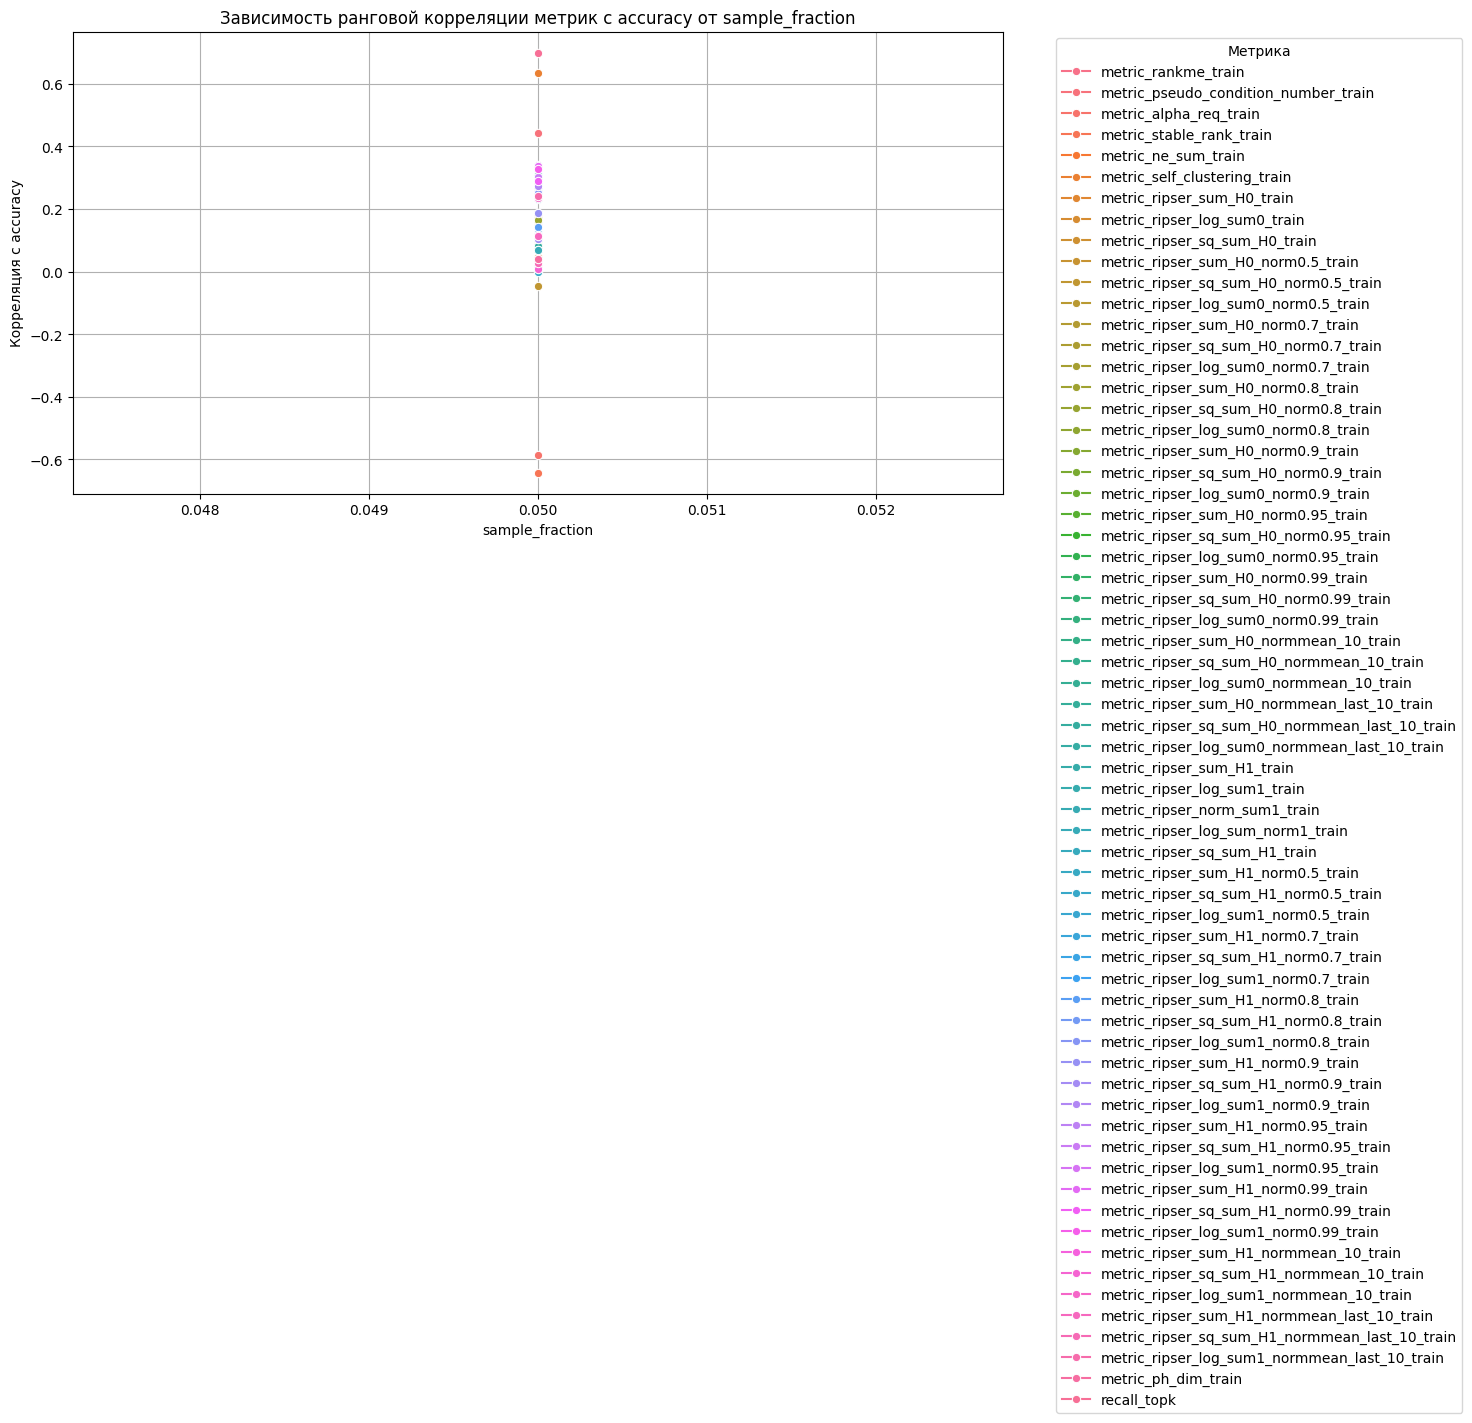

learning_rate


/tmp/ipykernel_1470740/693844687.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


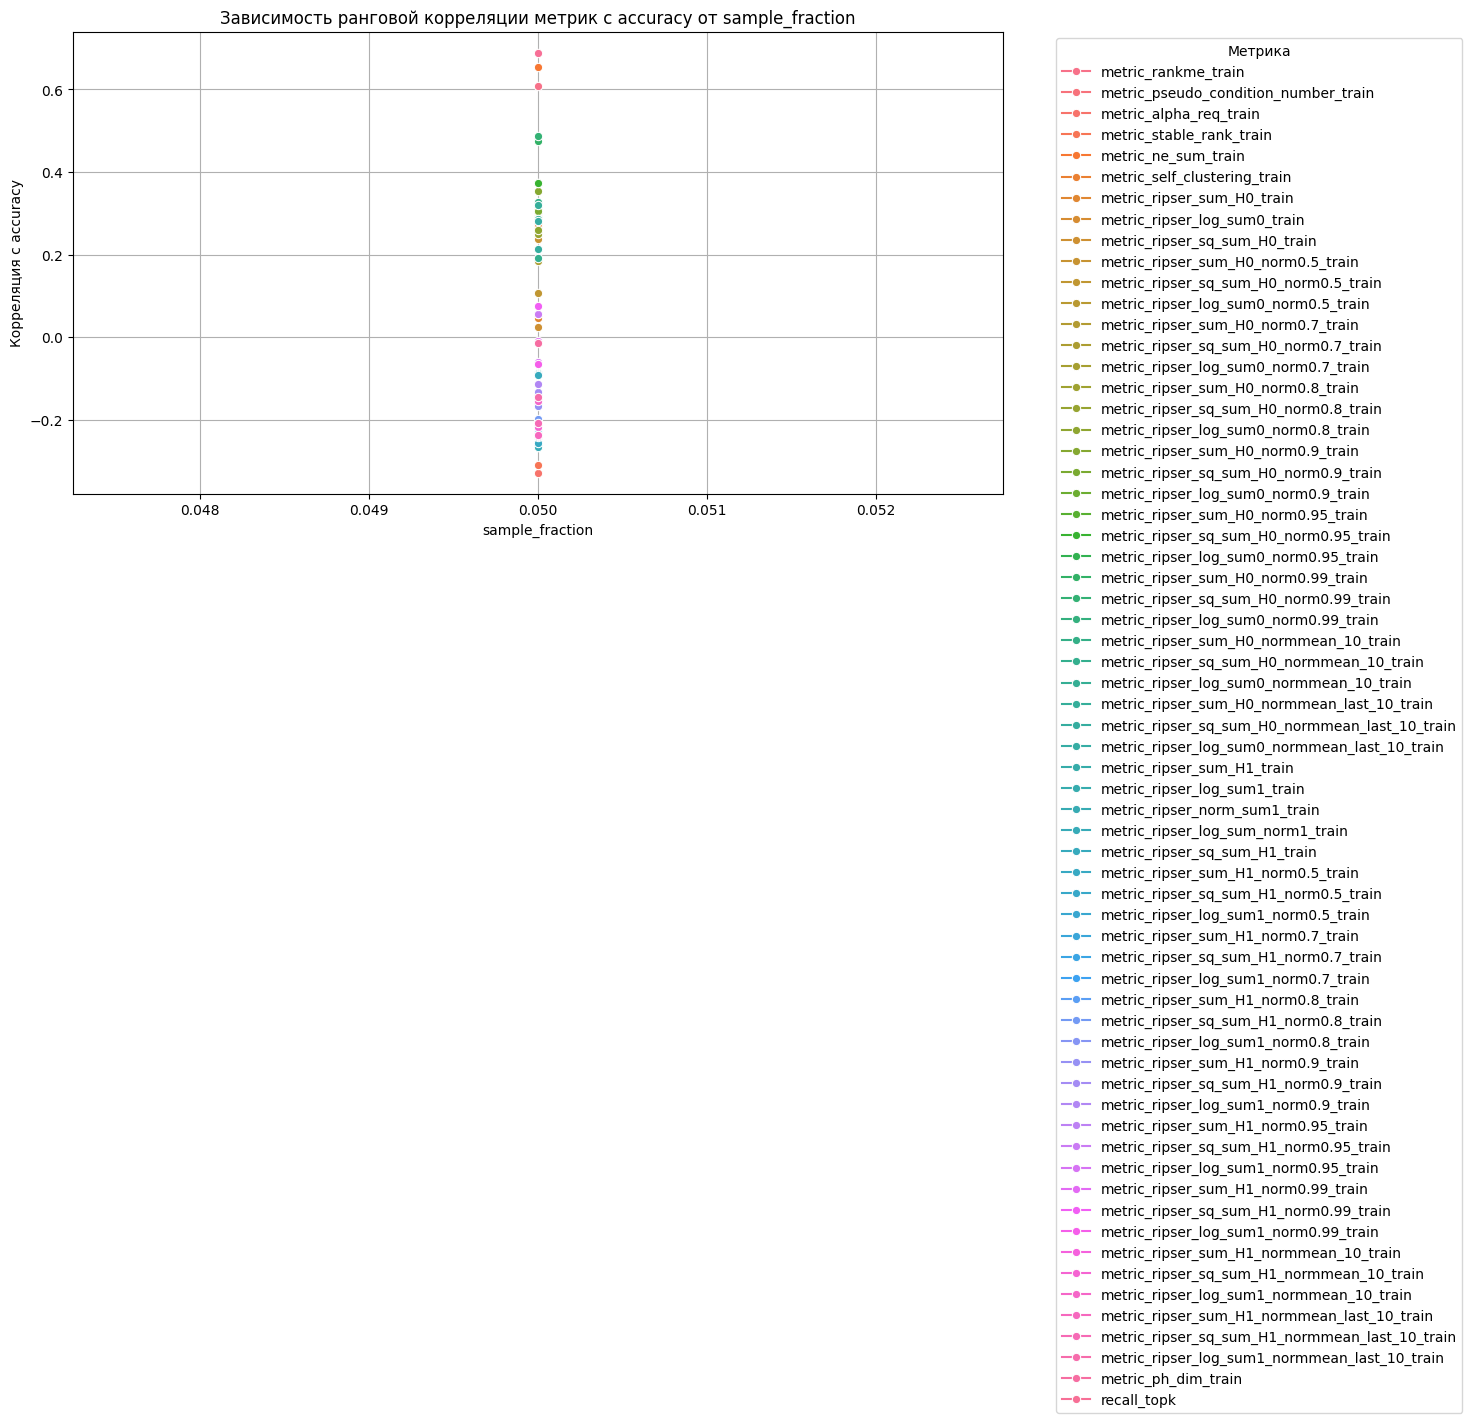

split_count


/tmp/ipykernel_1470740/693844687.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


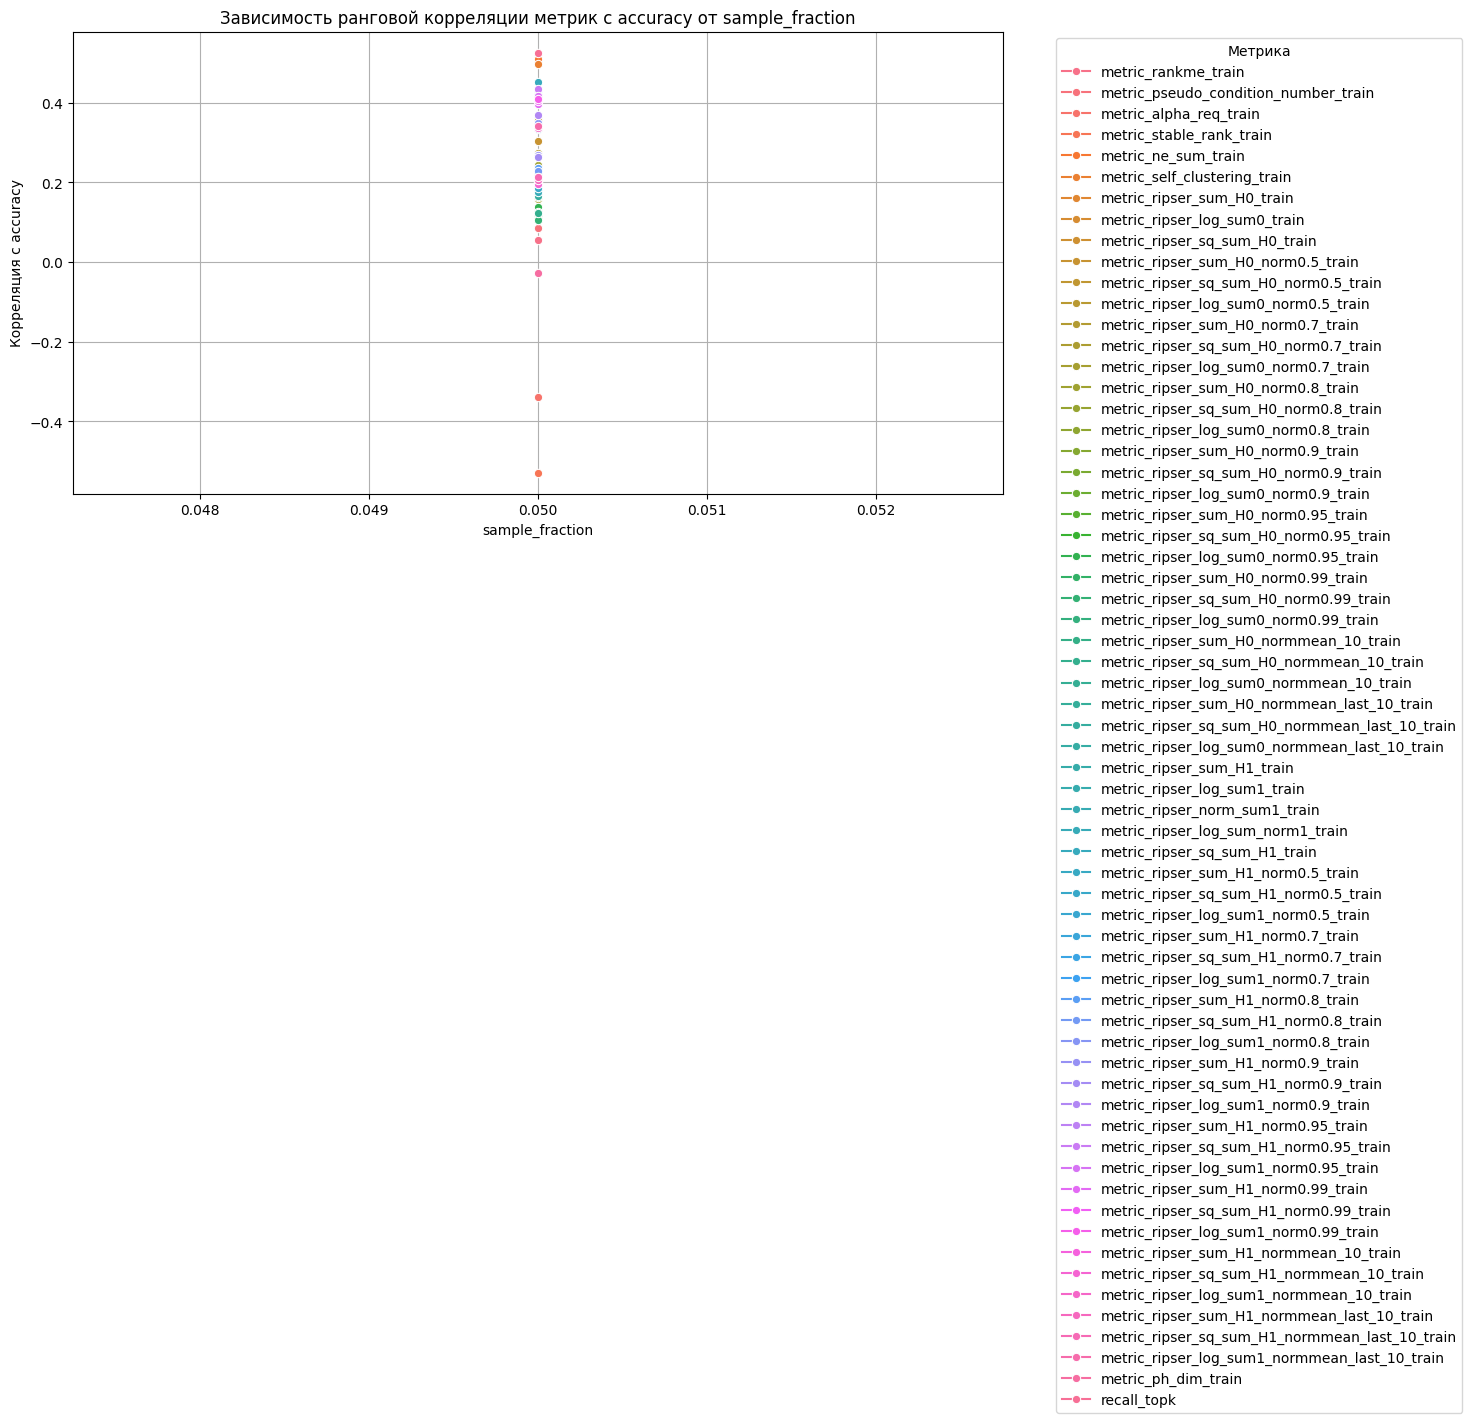

cnt_min


/tmp/ipykernel_1470740/693844687.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


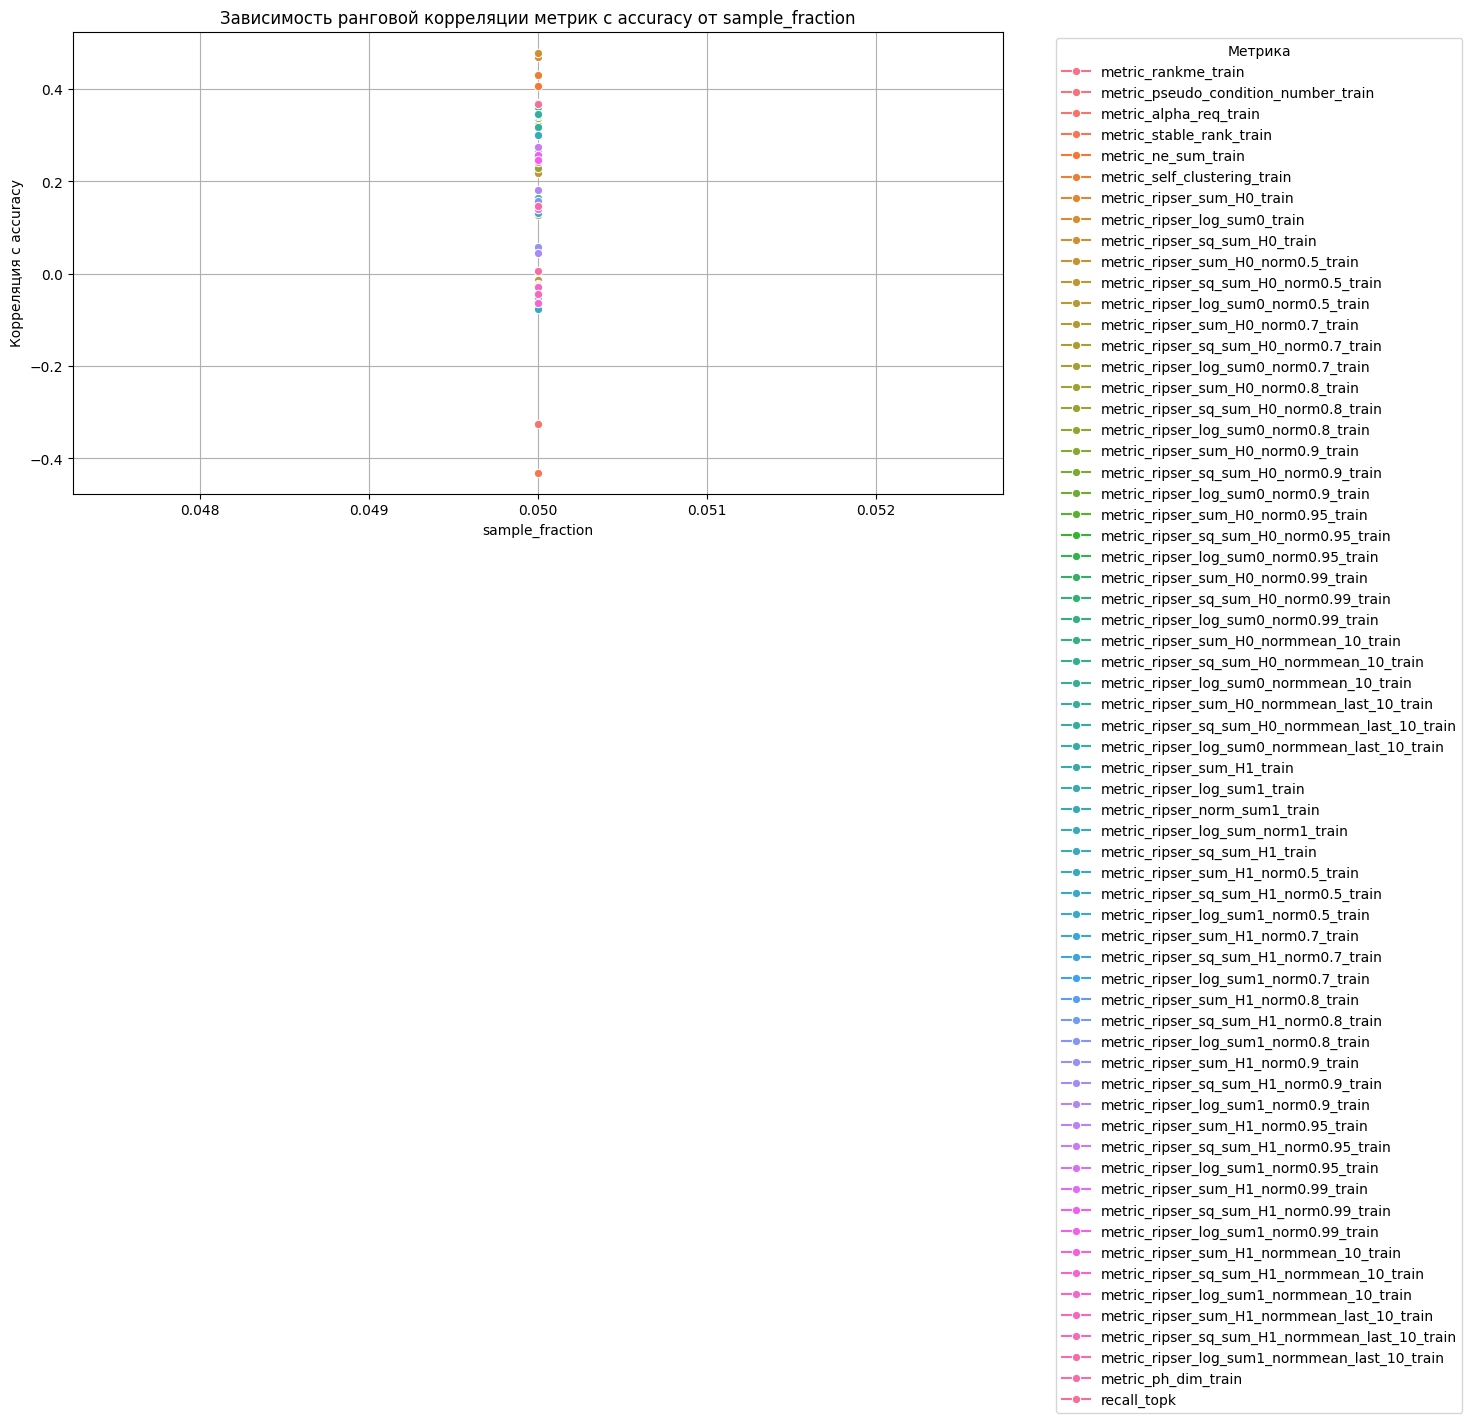

cnt_max


/tmp/ipykernel_1470740/693844687.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


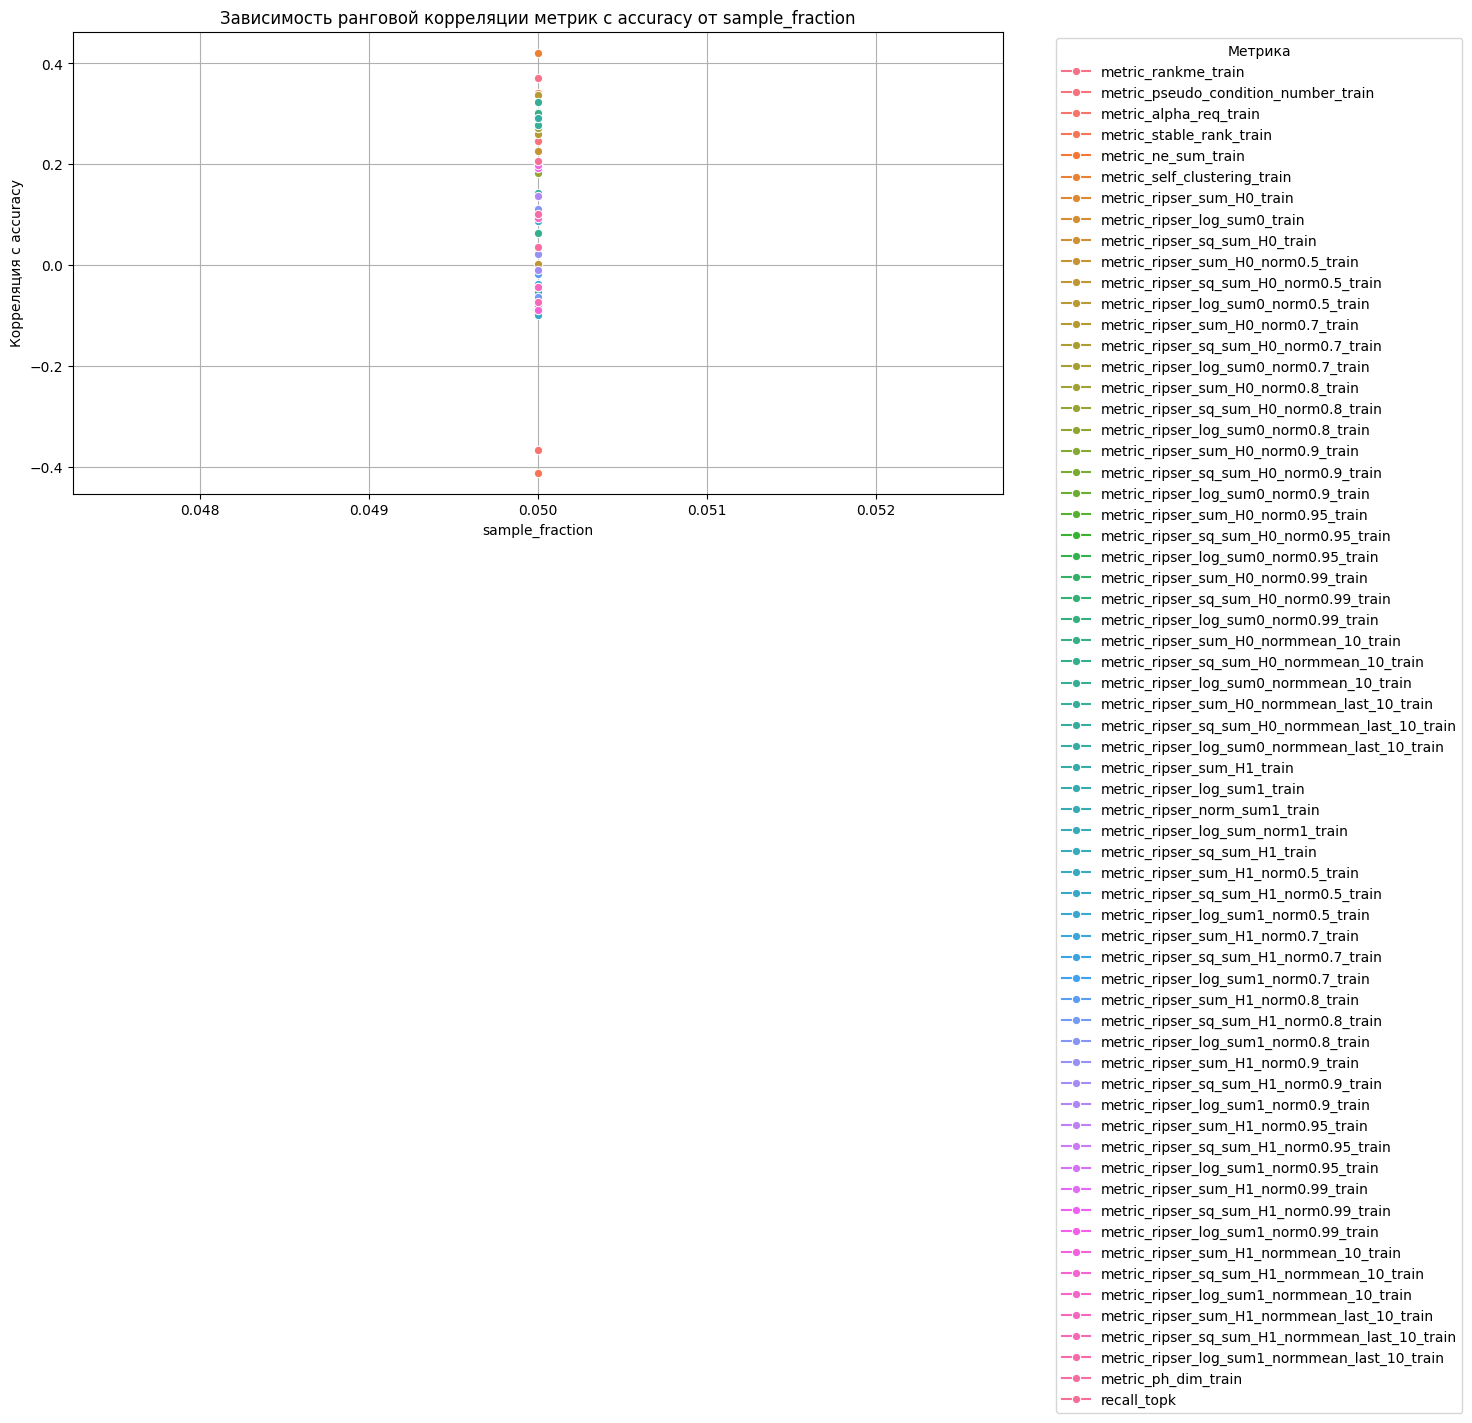

embedding_dim


/tmp/ipykernel_1470740/693844687.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


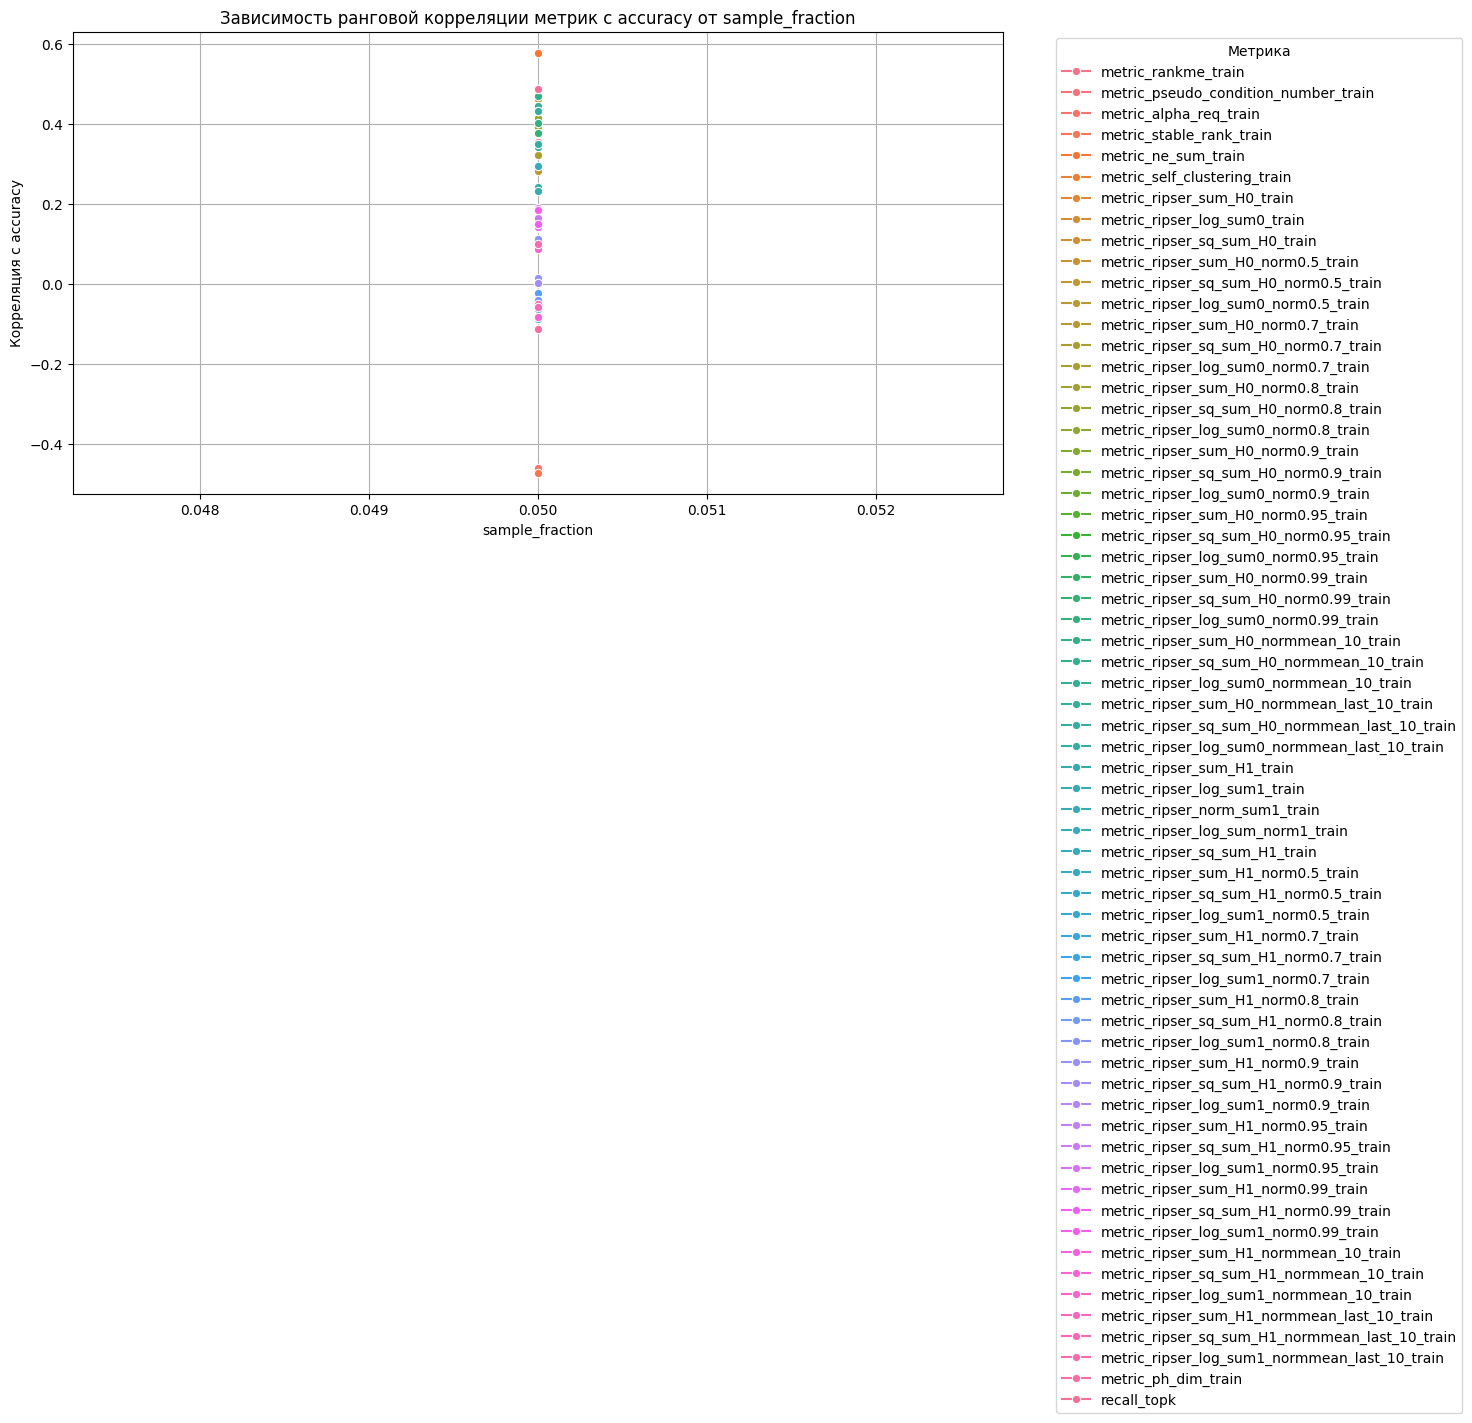

category_embedding_dim


/tmp/ipykernel_1470740/693844687.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


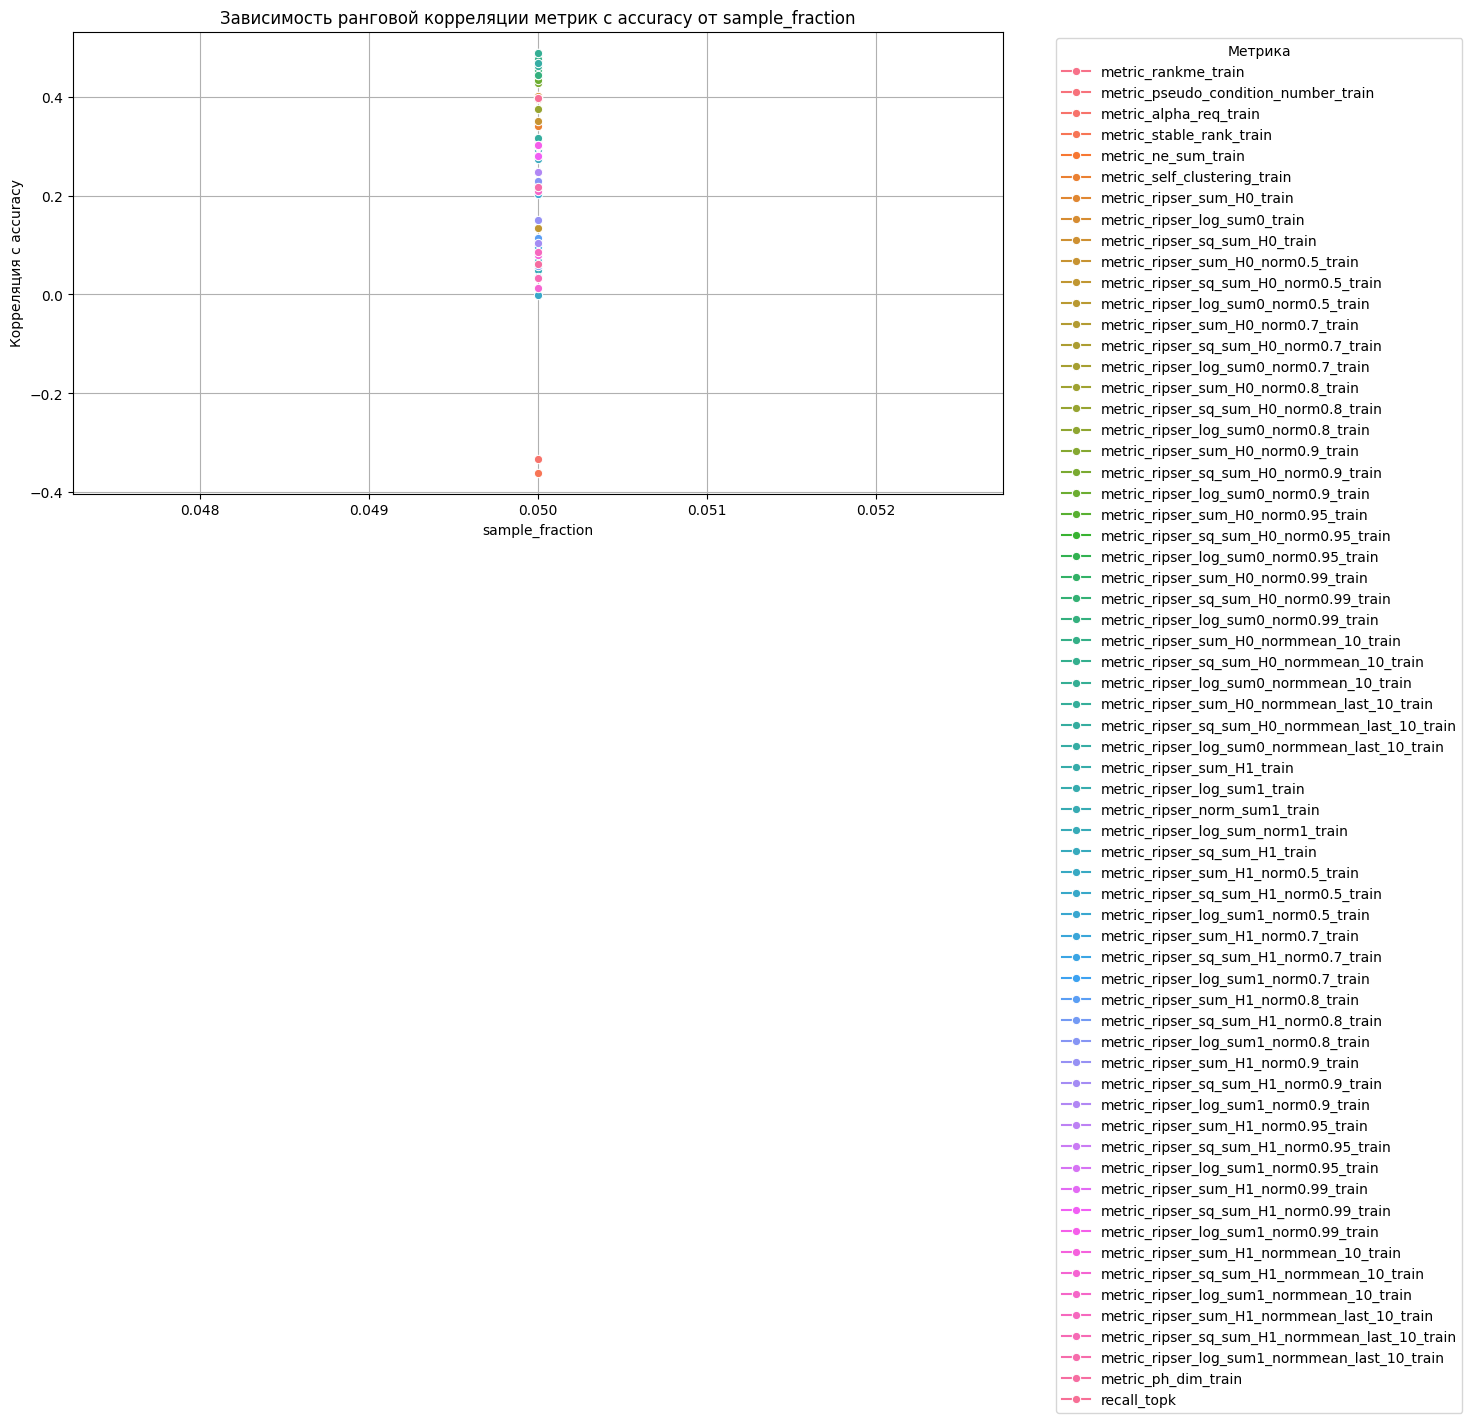

hidden_size


/tmp/ipykernel_1470740/693844687.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


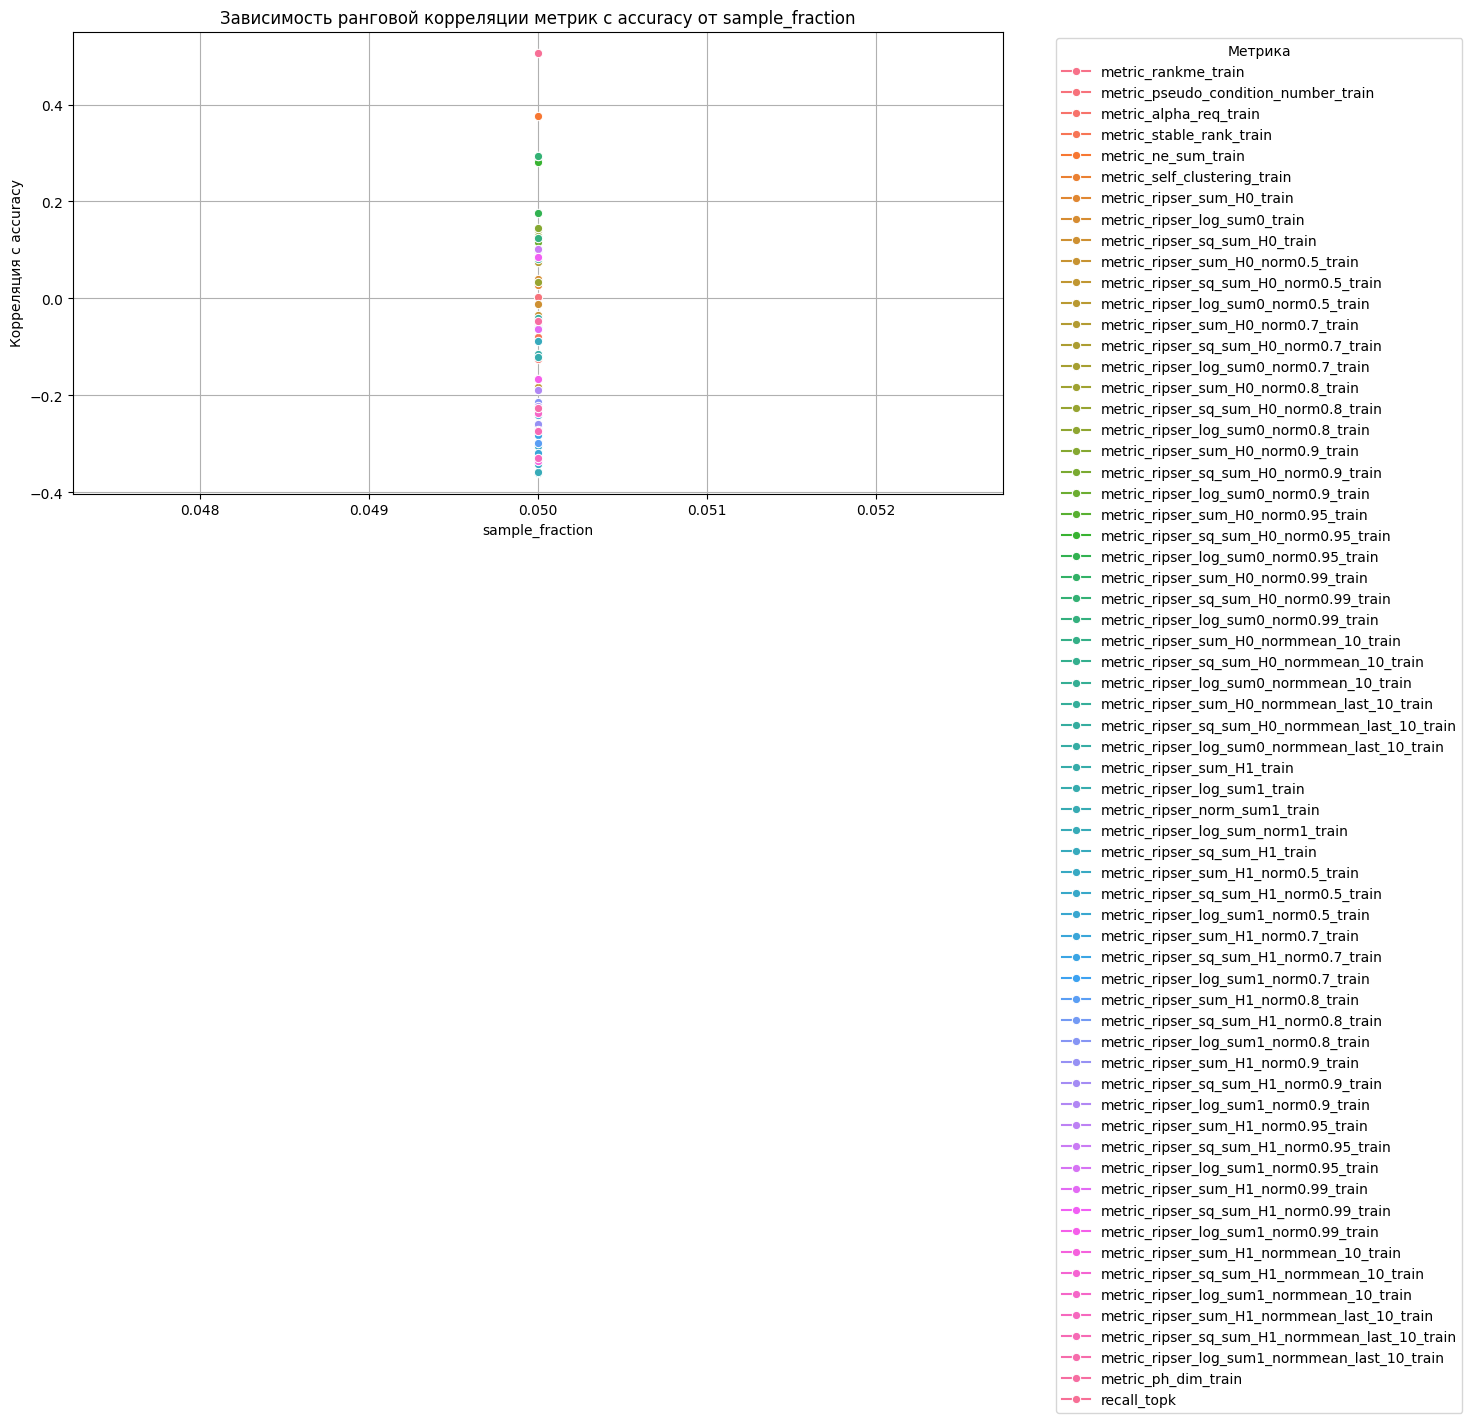

loss


/tmp/ipykernel_1470740/693844687.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


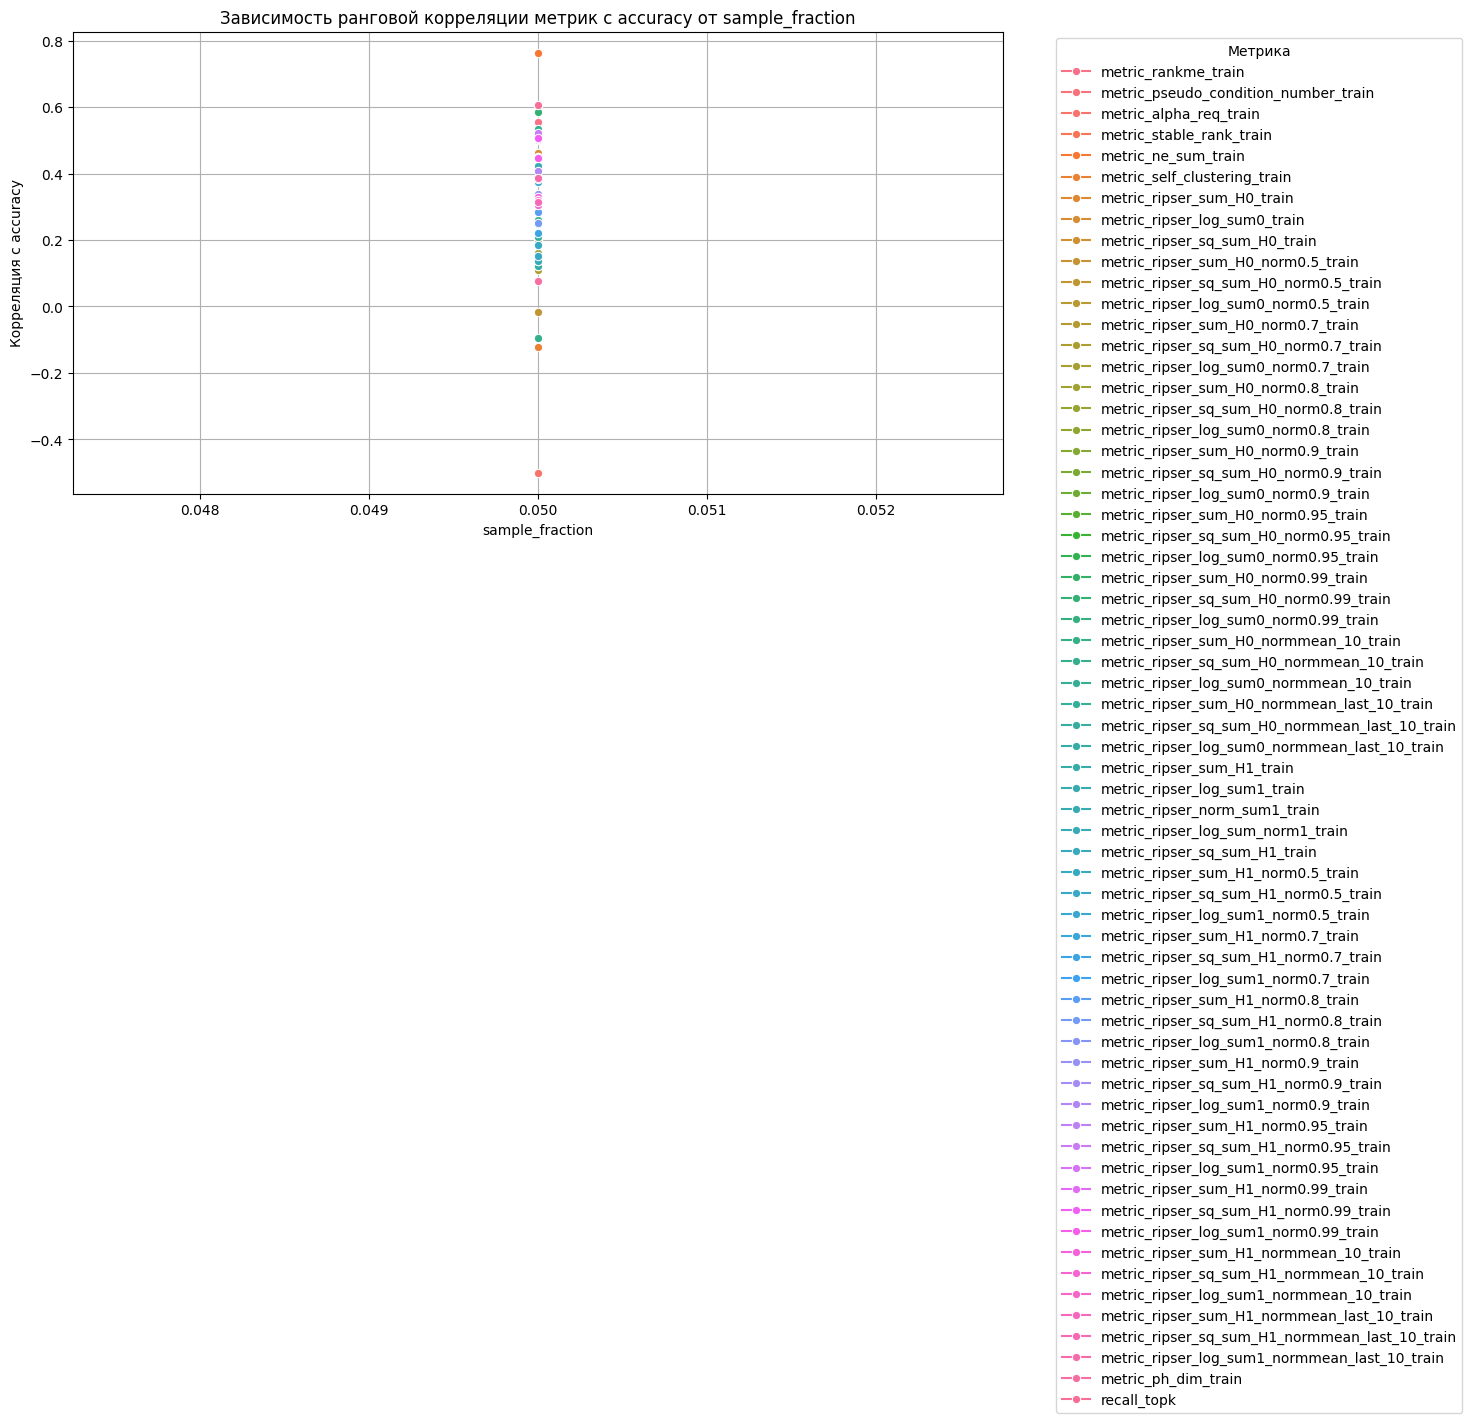

rnn_encoder_type


/tmp/ipykernel_1470740/693844687.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


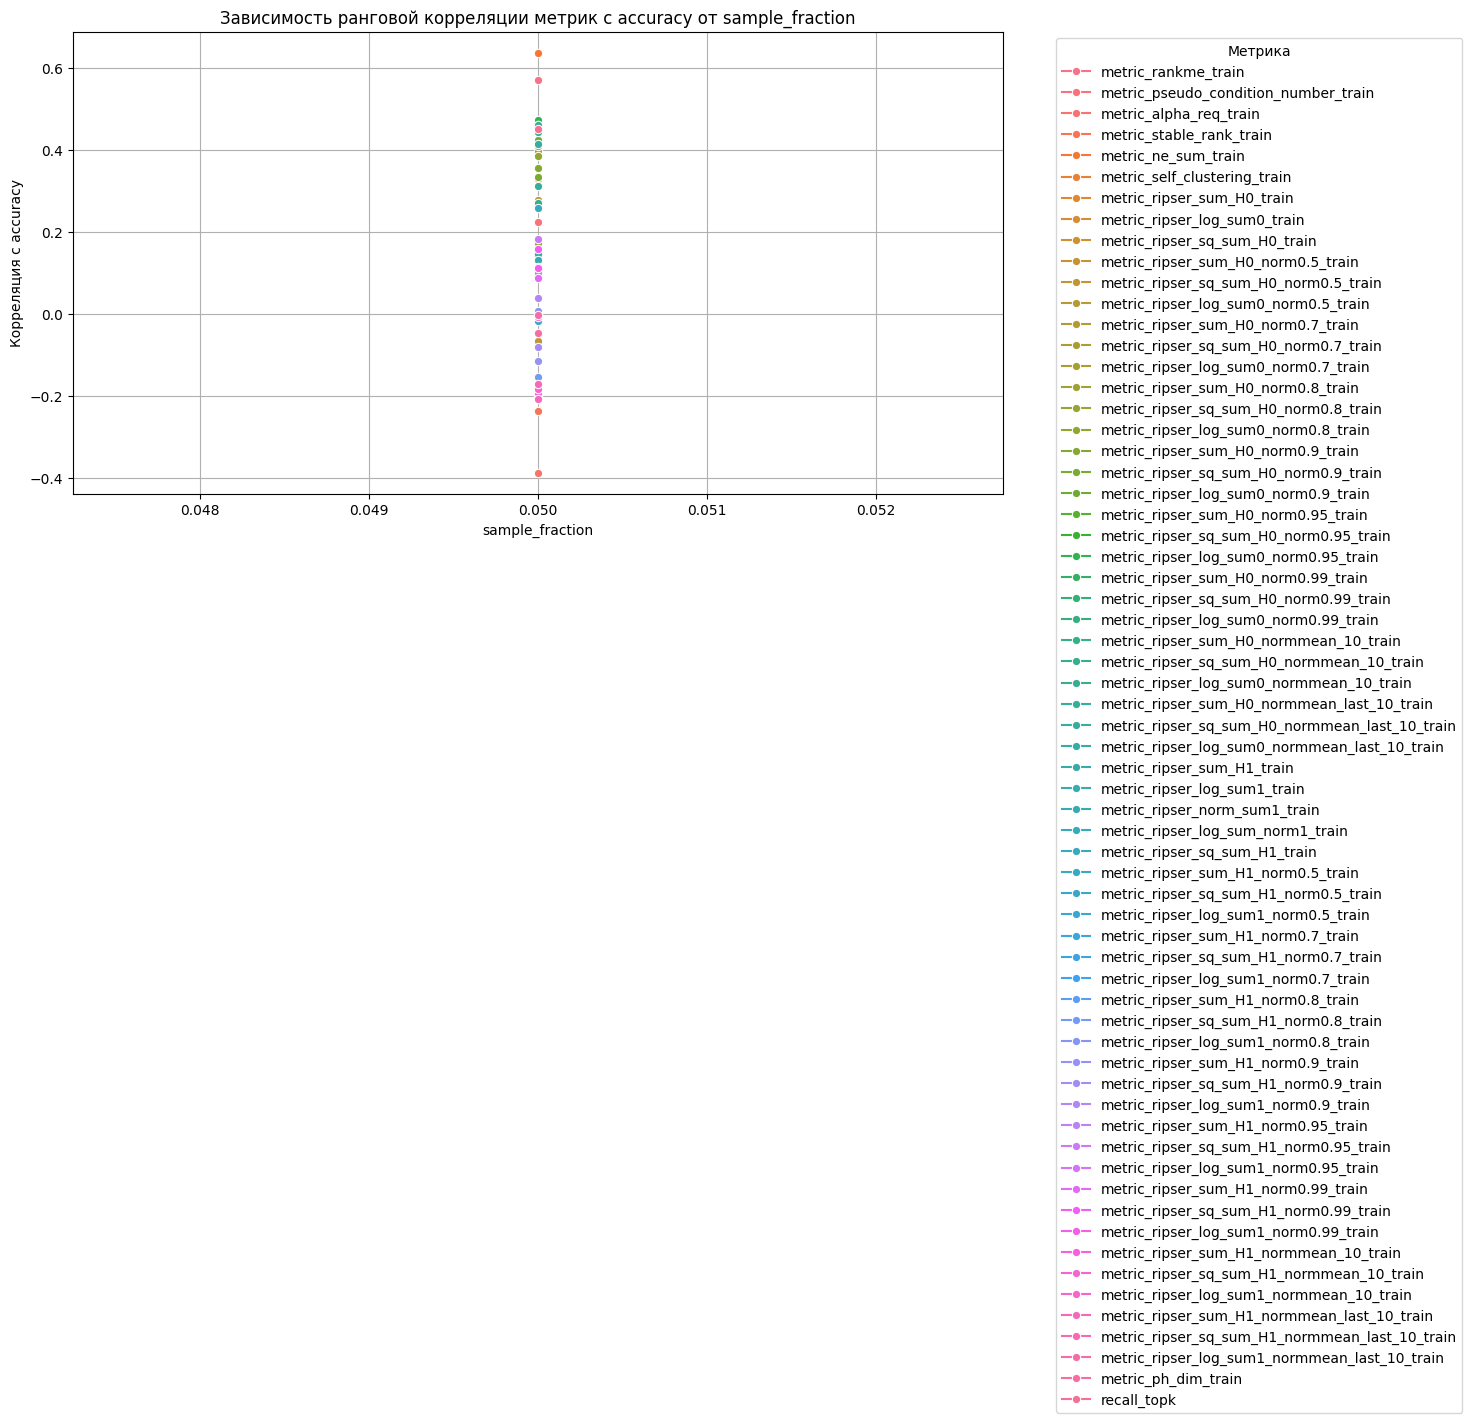

In [76]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    print(param)
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=corr_df, x="sample_fraction", y="corr", hue="metric", marker="o")
    plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
    plt.xlabel("sample_fraction")
    plt.ylabel("Корреляция с accuracy")
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
    plt.tight_layout()
    plt.show()

In [77]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    mean_corr = corr_df[corr_df['sample_fraction'] < 0.5].groupby("metric")["corr"].mean().sort_values(ascending=False)
    print(param)
    print(mean_corr)

batch_size
metric
recall_topk                                  0.699371
metric_self_clustering_train                 0.634443
metric_pseudo_condition_number_train         0.443371
metric_ripser_sum_H1_norm0.95_train          0.341525
metric_ripser_sum_H1_norm0.99_train          0.336743
                                               ...   
metric_ripser_sq_sum_H1_normmean_10_train    0.007494
metric_ripser_sq_sum_H1_norm0.5_train       -0.000648
metric_ripser_sq_sum_H0_norm0.5_train       -0.046042
metric_alpha_req_train                      -0.584601
metric_stable_rank_train                    -0.641576
Name: corr, Length: 64, dtype: float64
learning_rate
metric
recall_topk                               0.689603
metric_ne_sum_train                       0.655404
metric_rankme_train                       0.607813
metric_ripser_sq_sum_H0_norm0.99_train    0.487884
metric_ripser_sum_H0_norm0.99_train       0.475637
                                            ...   
metric_ripser_sum_H1_n

# Score of best hyperparams by metric

In [78]:
from collections import defaultdict
params_cols=['batch_size', 
             'learning_rate', 
             'split_count',
             'cnt_min', 'cnt_max', 'embedding_dim', 
             'category_embedding_dim', 
             'hidden_size', 
             'loss', 
             'rnn_encoder_type']

corr_records = defaultdict(list)
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for param in params_cols:
        curr_params = [p for p in params_cols if p != param]
        combined = "_".join(curr_params)
        sub[combined] = sub[curr_params].astype(str).sum(axis=1)
        for metric in metric_columns:
            sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
                sub['roc_auc'], method='spearman'))
            for check, check_data in sub.groupby(combined):   
                if check_data[param].nunique() <= 1:
                    continue
                if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                    curr = ~np.isnan(check_data[metric])
                    pick = check_data['roc_auc'].values[curr][
                        np.argmax(check_data[metric].values[curr])]
                    corr_records[param].append({
                        "sample_fraction": frac,
                        "metric": metric,
                        "auc": pick
                    })

batch_size


/tmp/ipykernel_1470740/3567089855.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


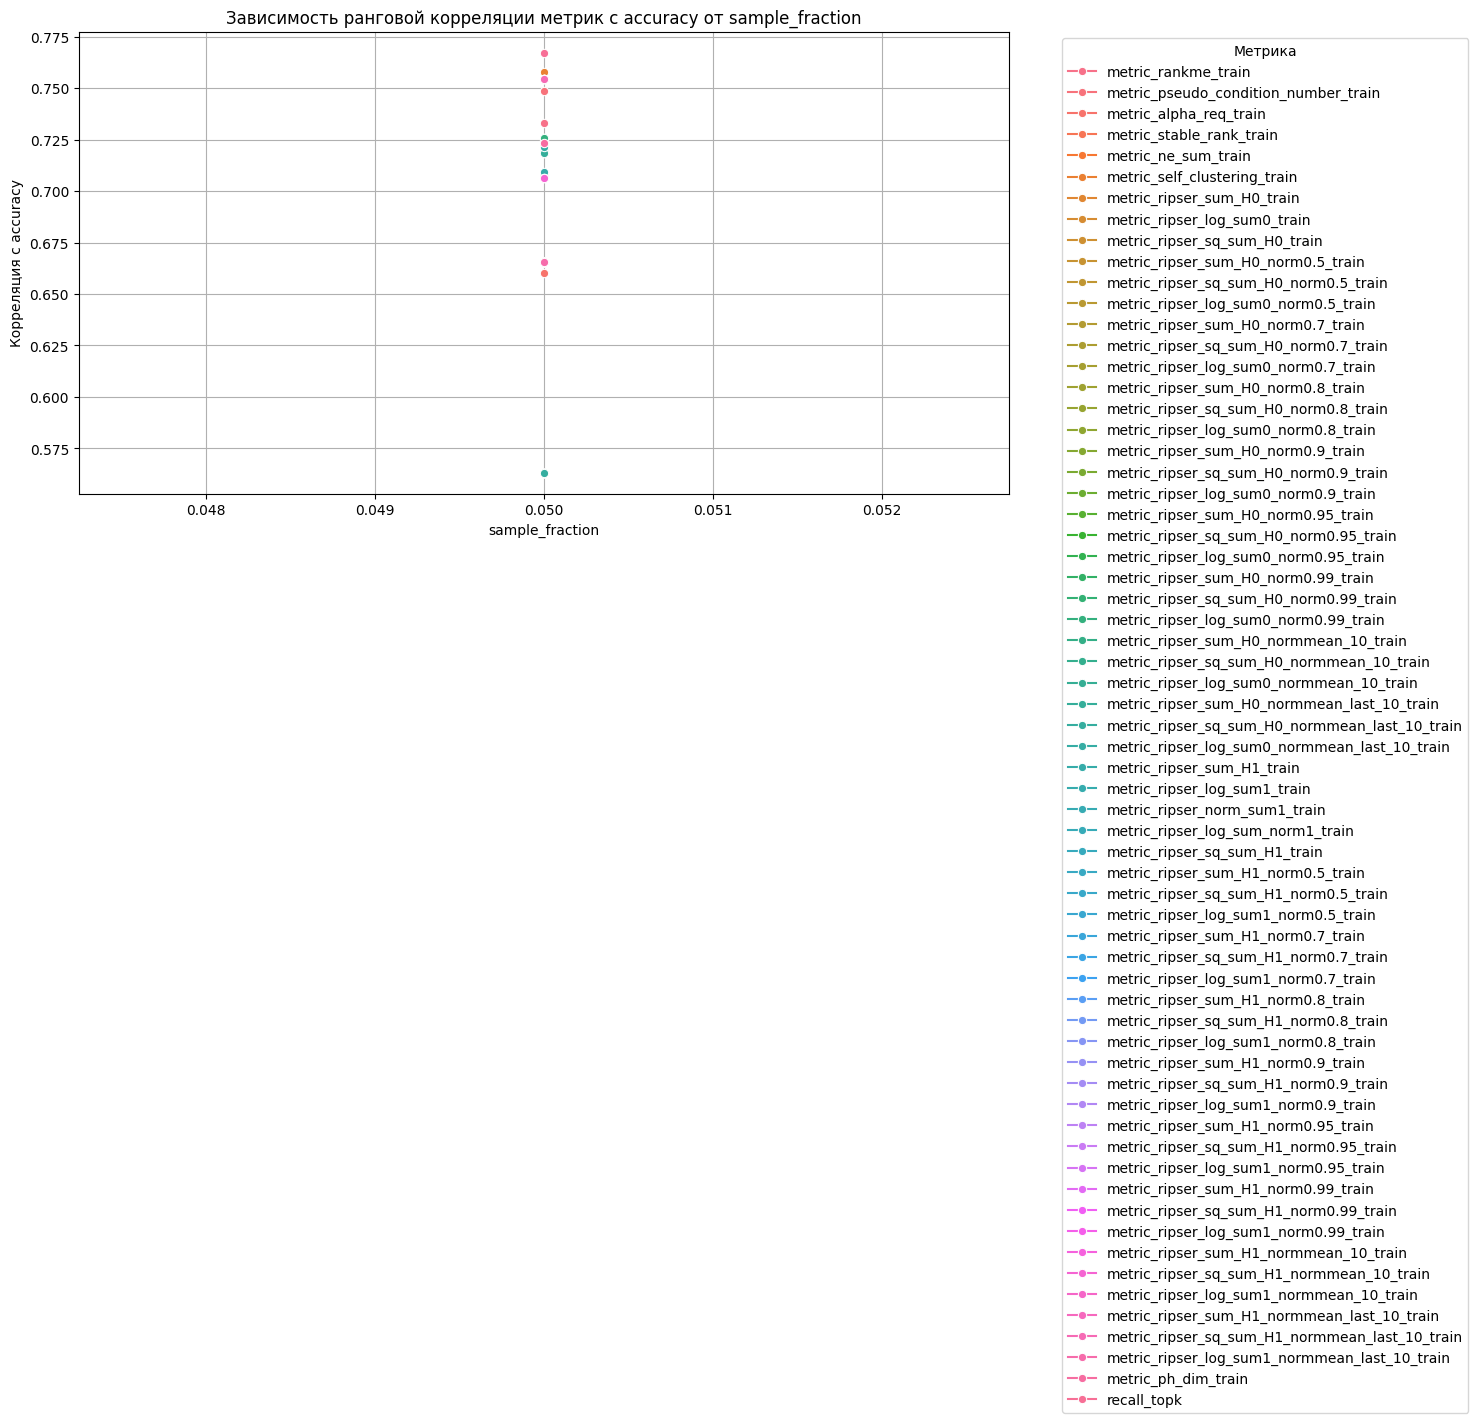

learning_rate


/tmp/ipykernel_1470740/3567089855.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


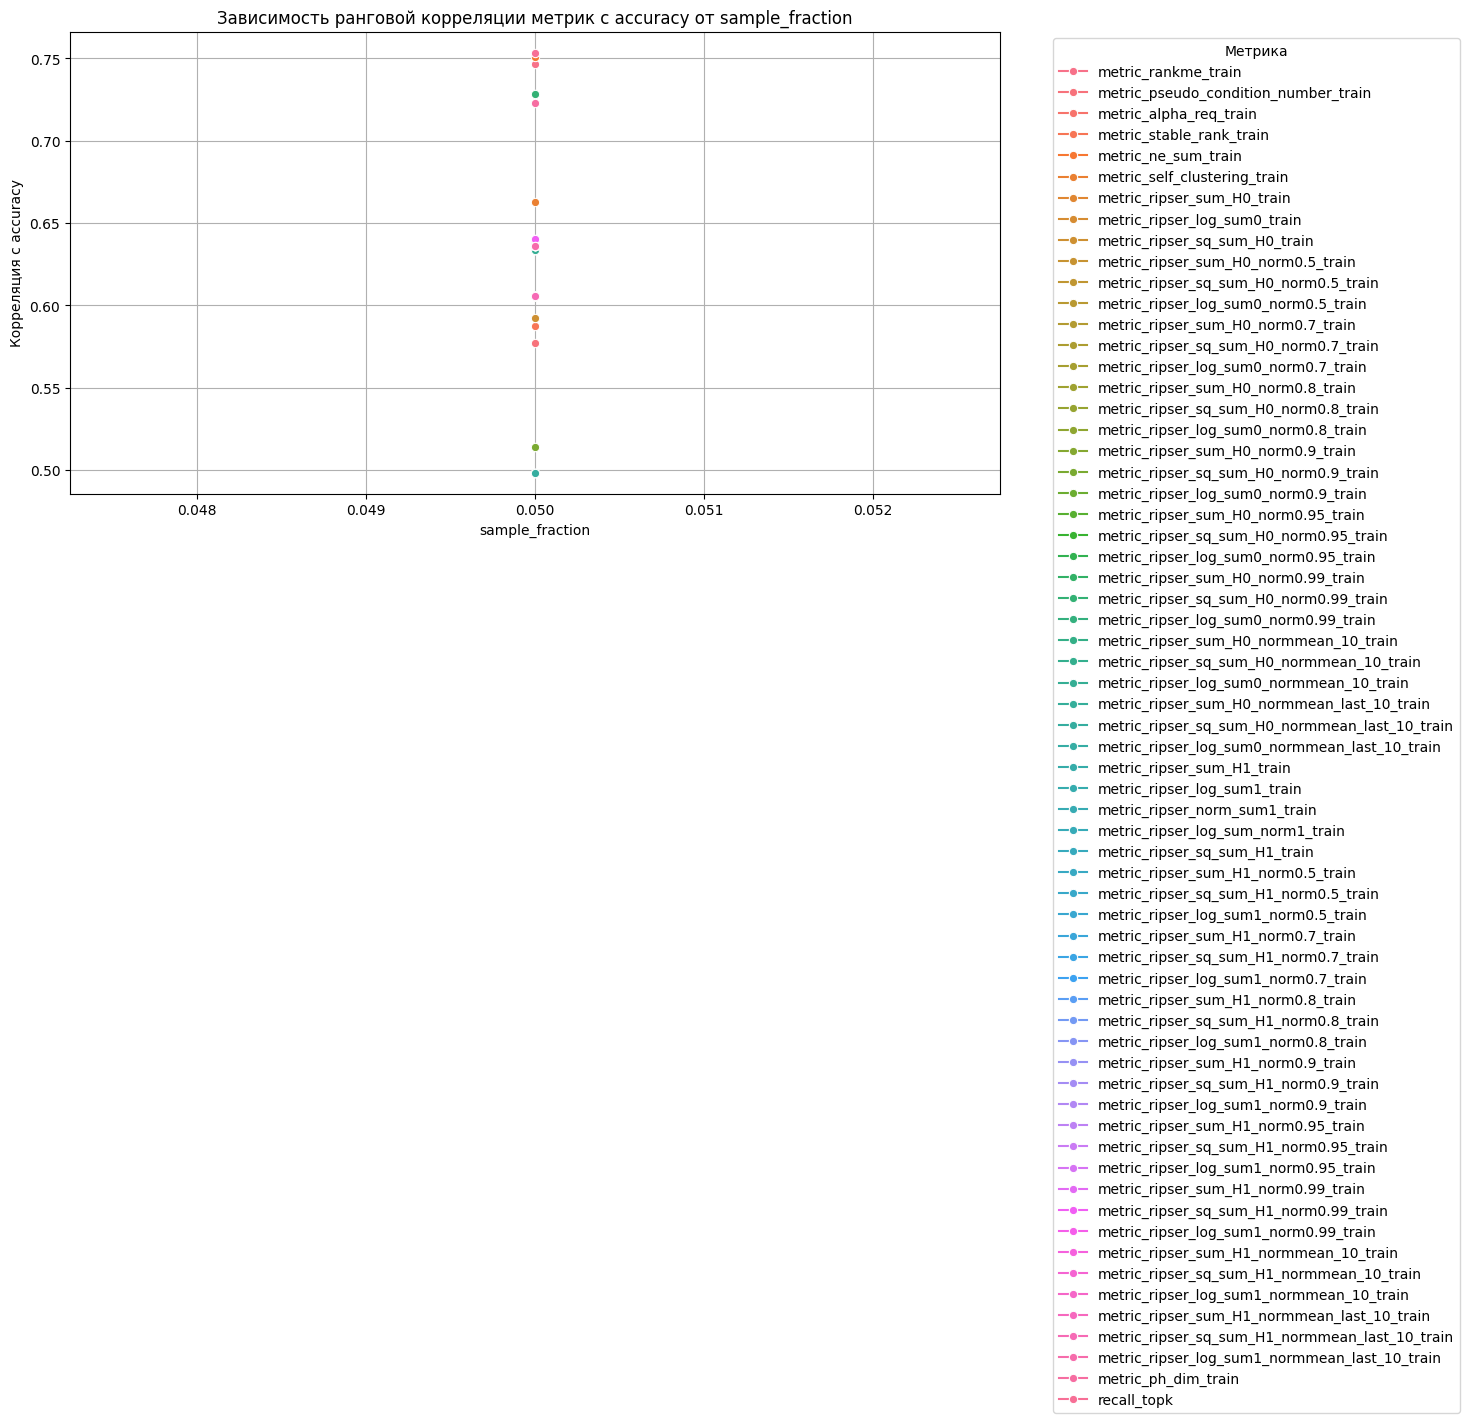

split_count


/tmp/ipykernel_1470740/3567089855.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


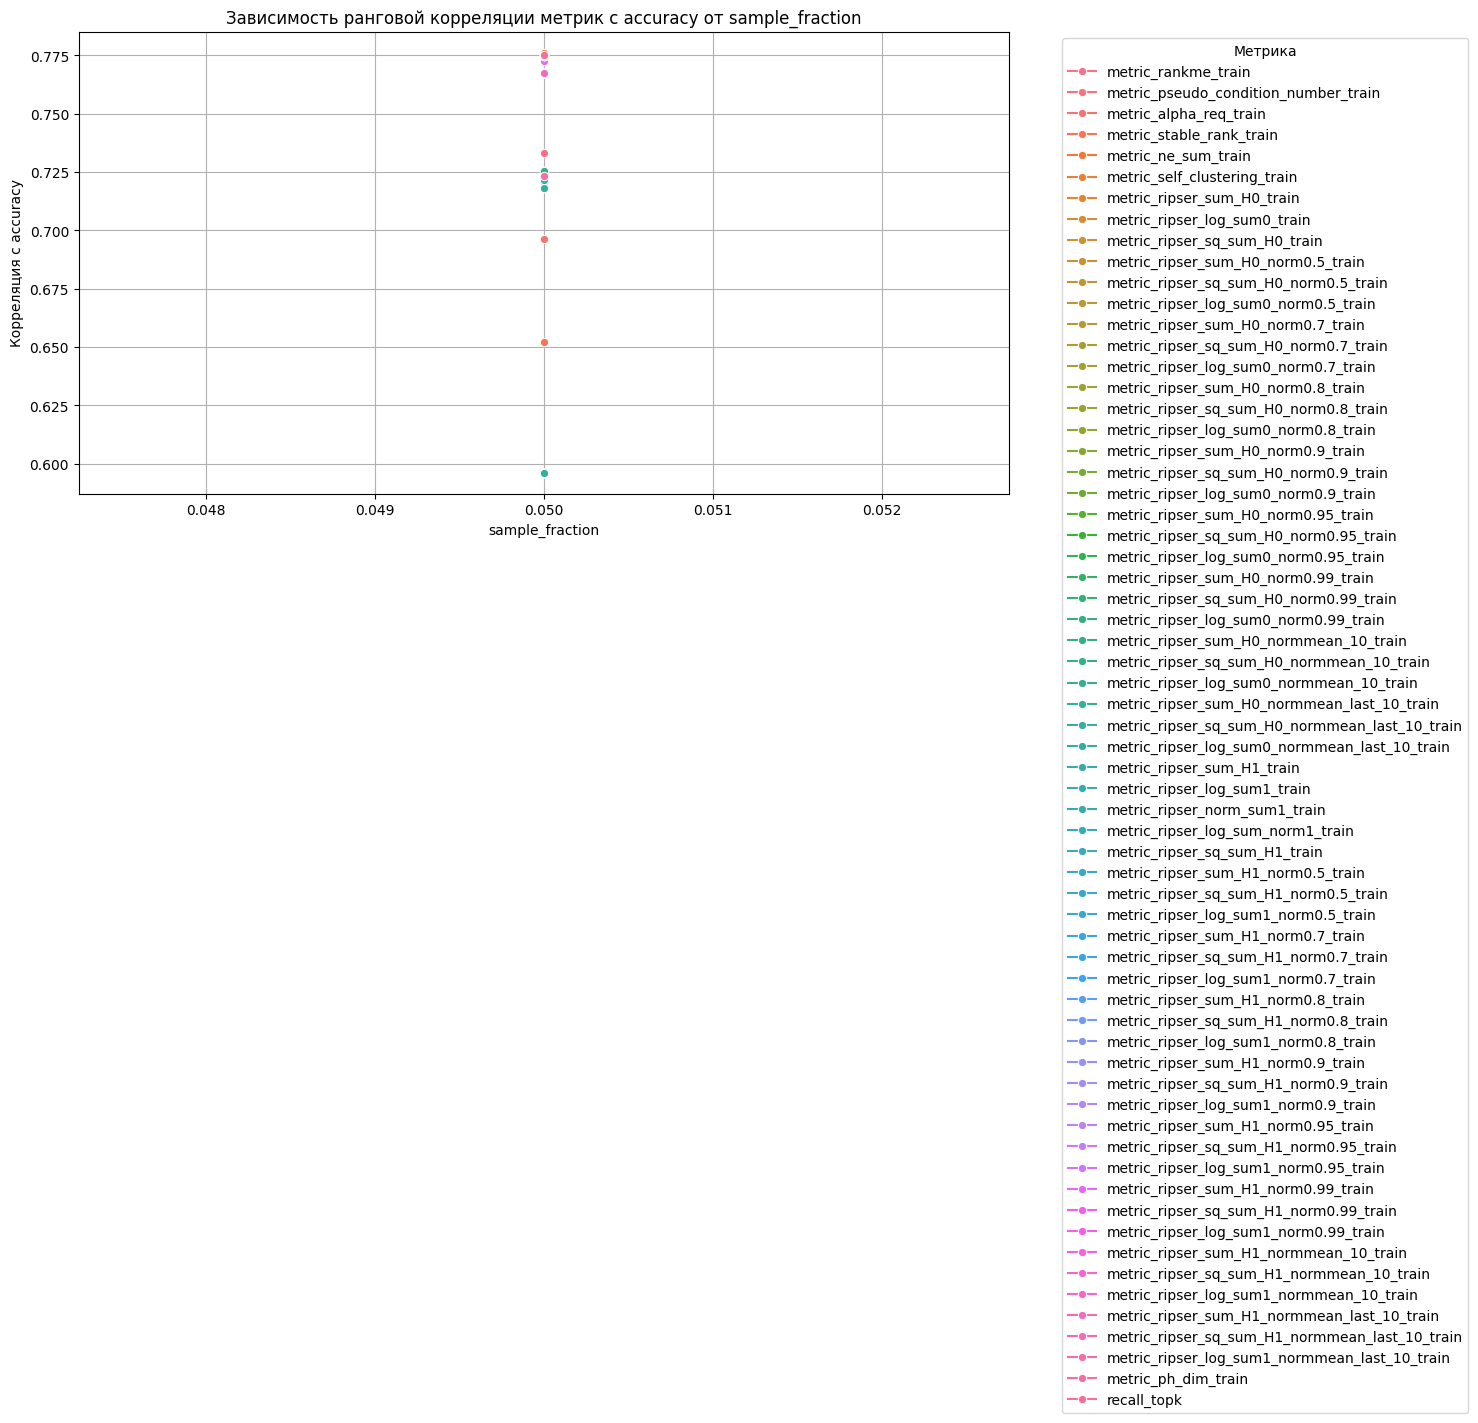

cnt_min


/tmp/ipykernel_1470740/3567089855.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


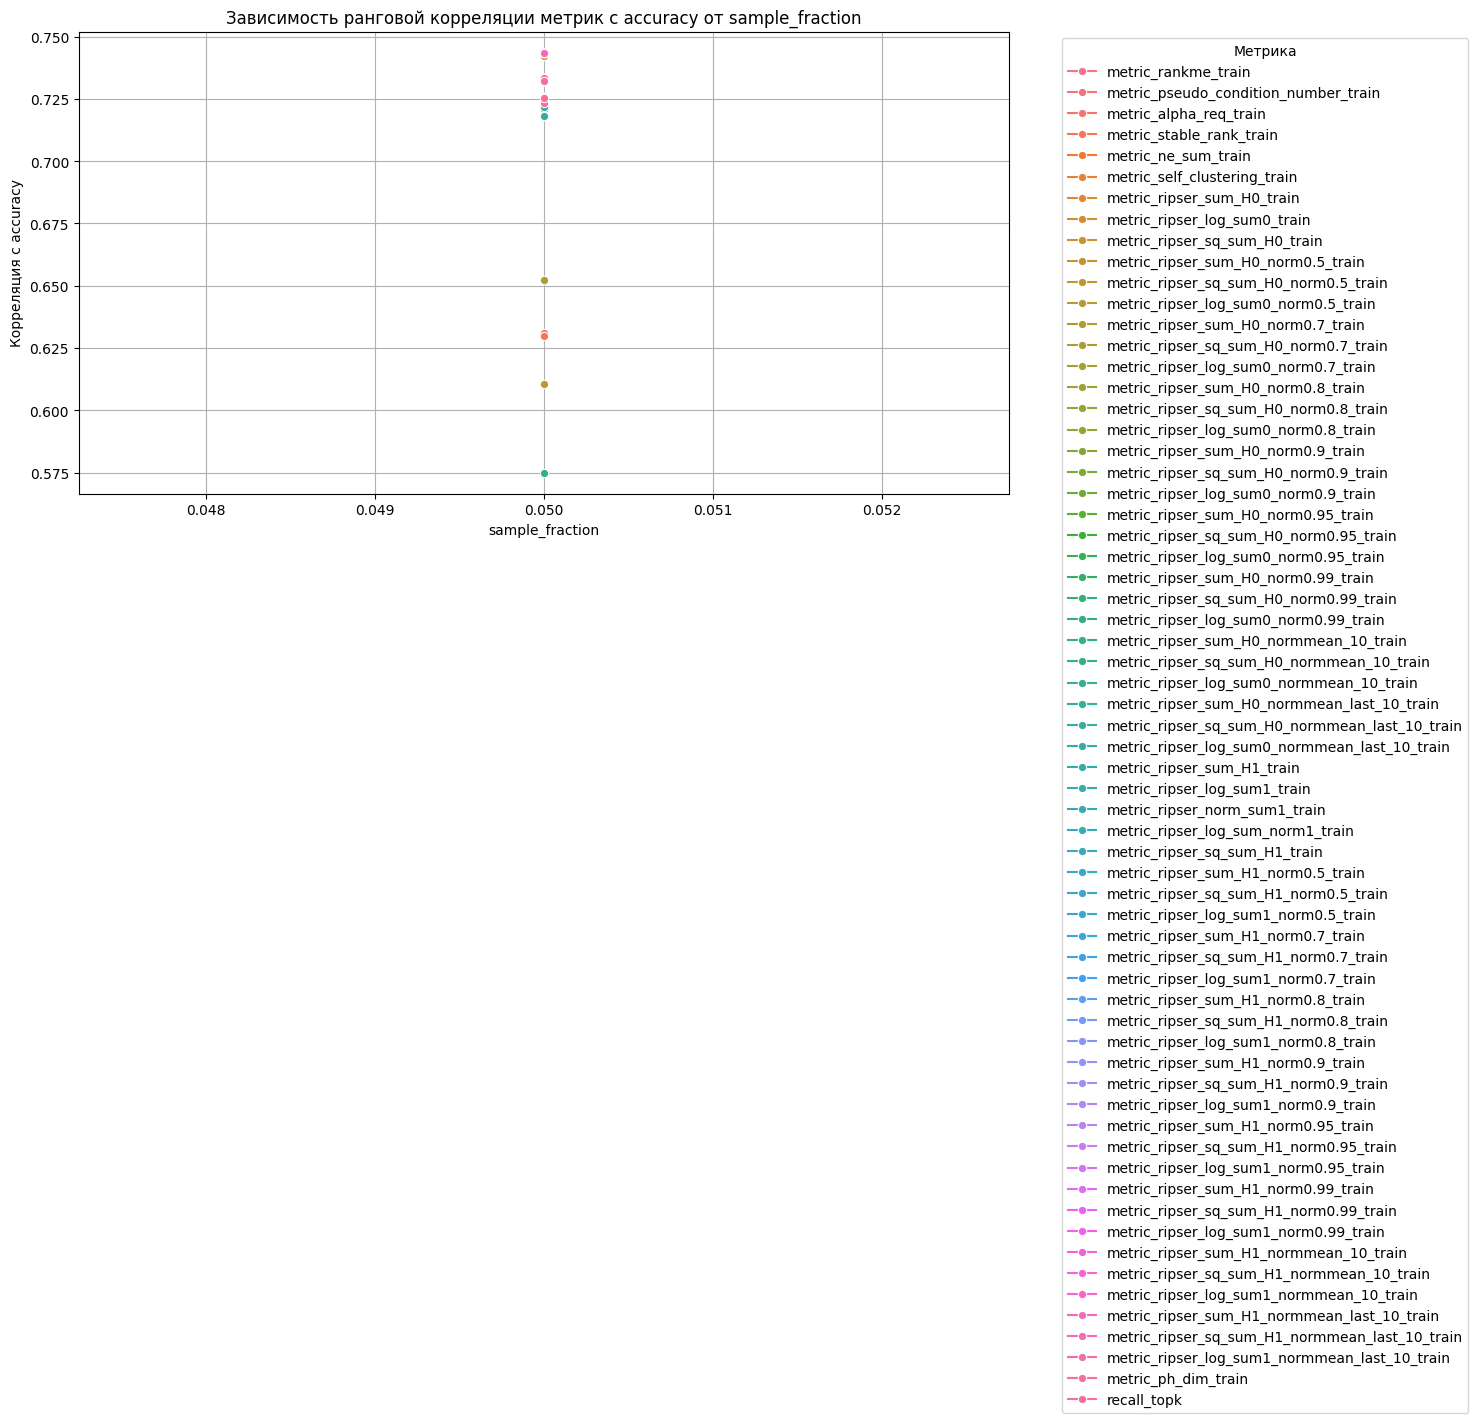

cnt_max


/tmp/ipykernel_1470740/3567089855.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


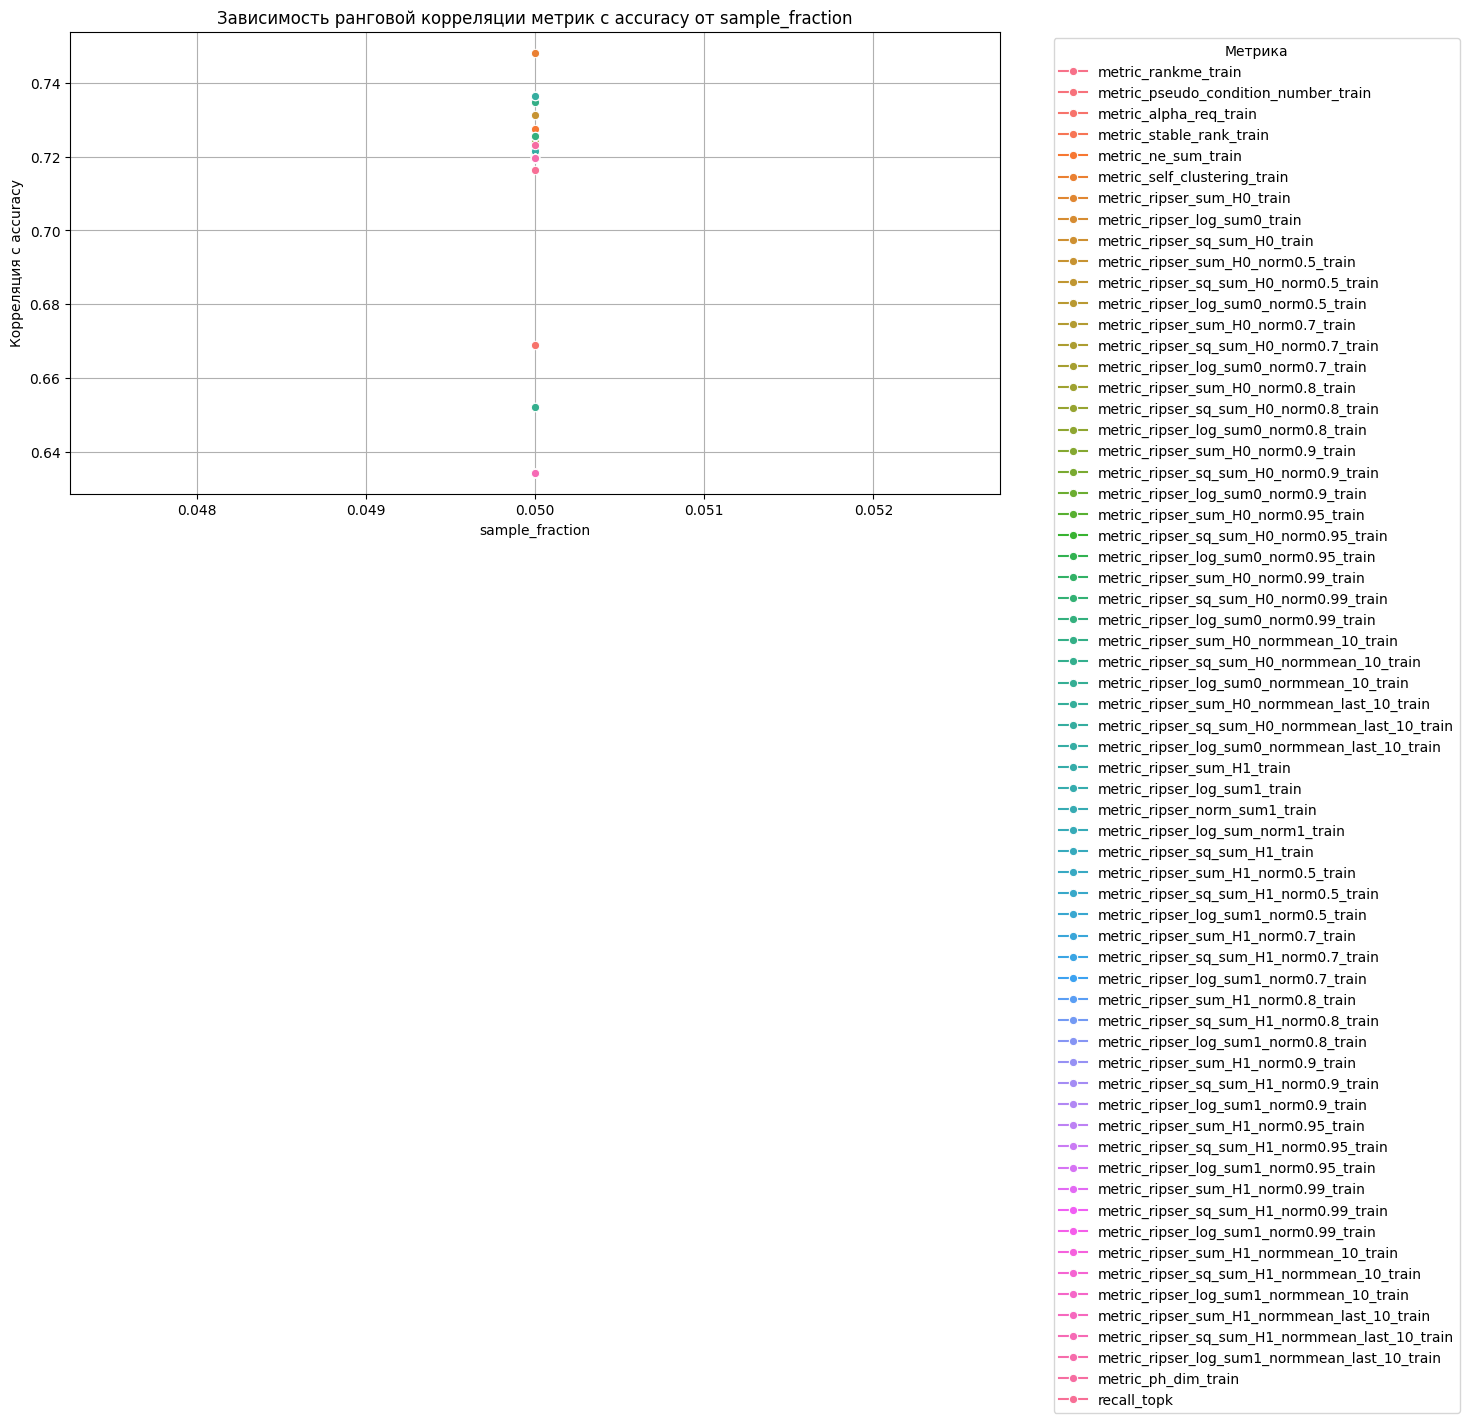

embedding_dim


/tmp/ipykernel_1470740/3567089855.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


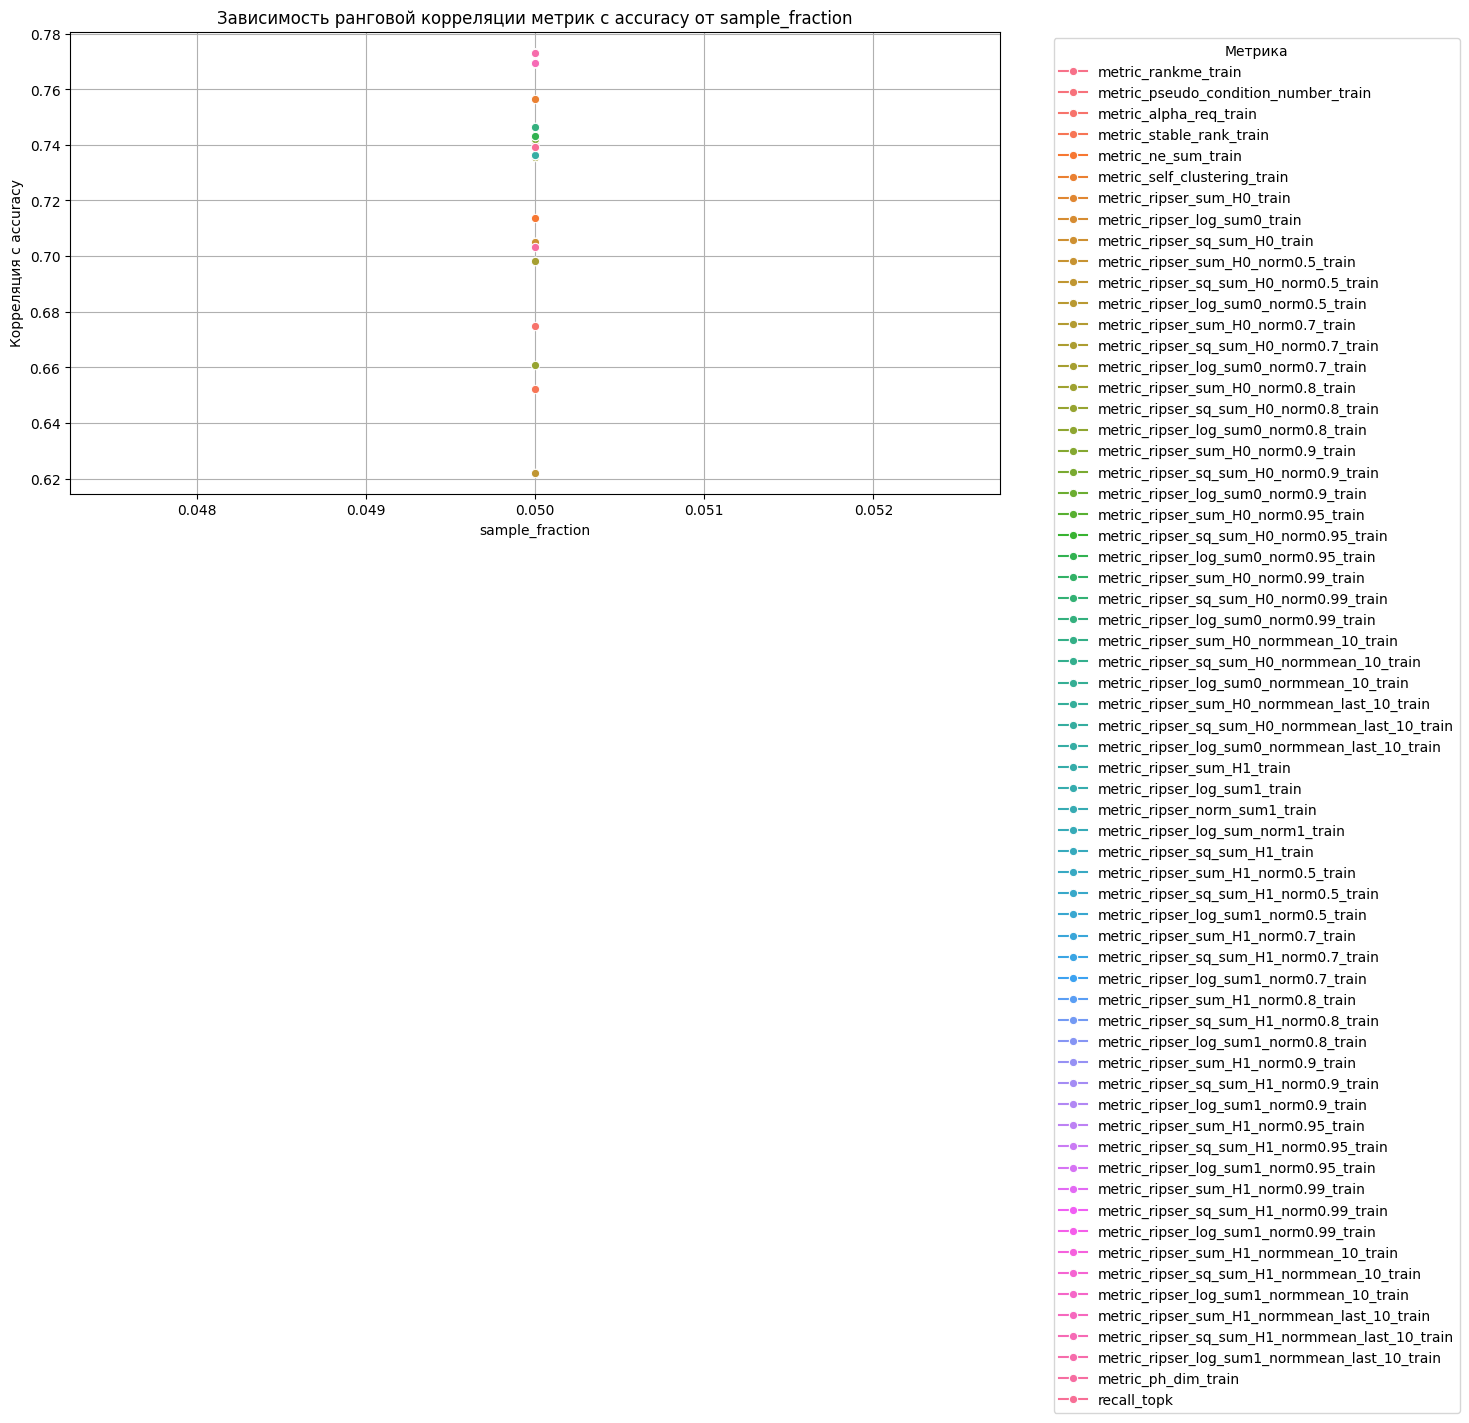

category_embedding_dim


/tmp/ipykernel_1470740/3567089855.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


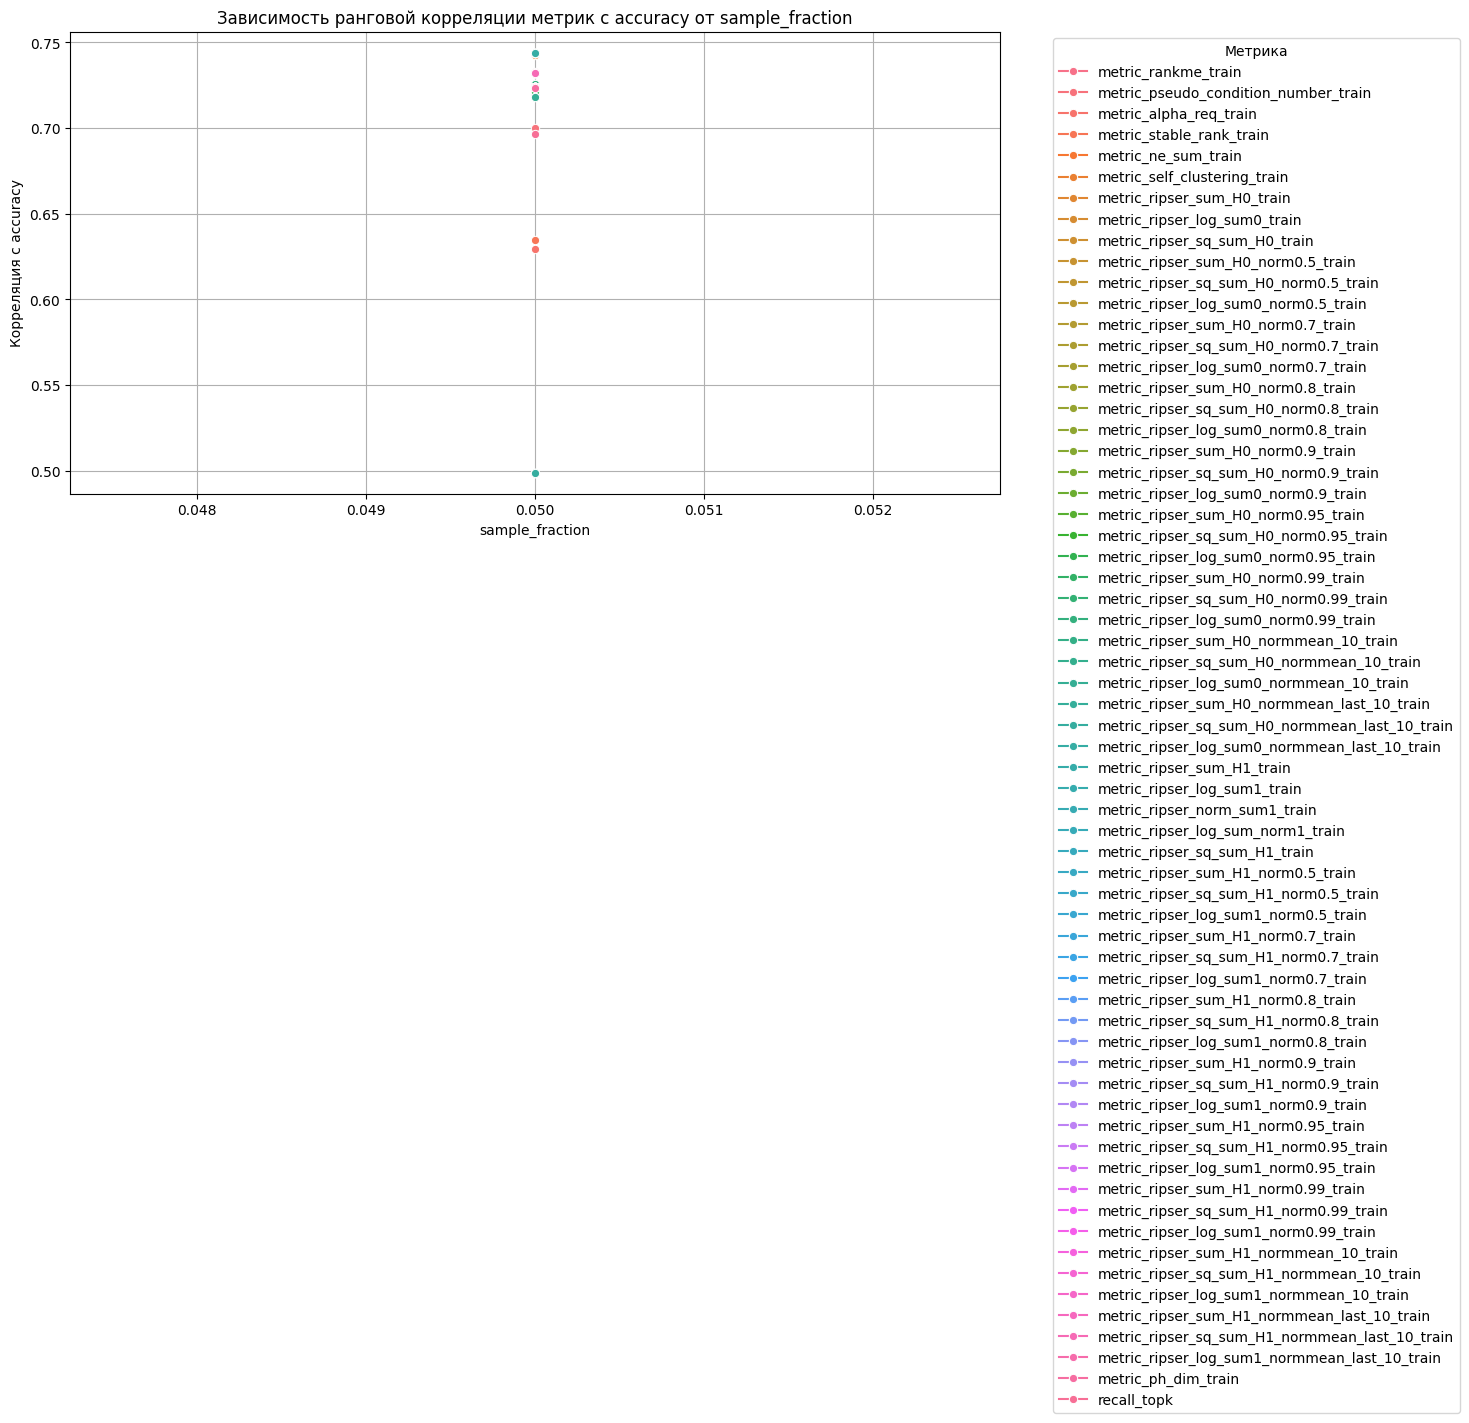

hidden_size


/tmp/ipykernel_1470740/3567089855.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


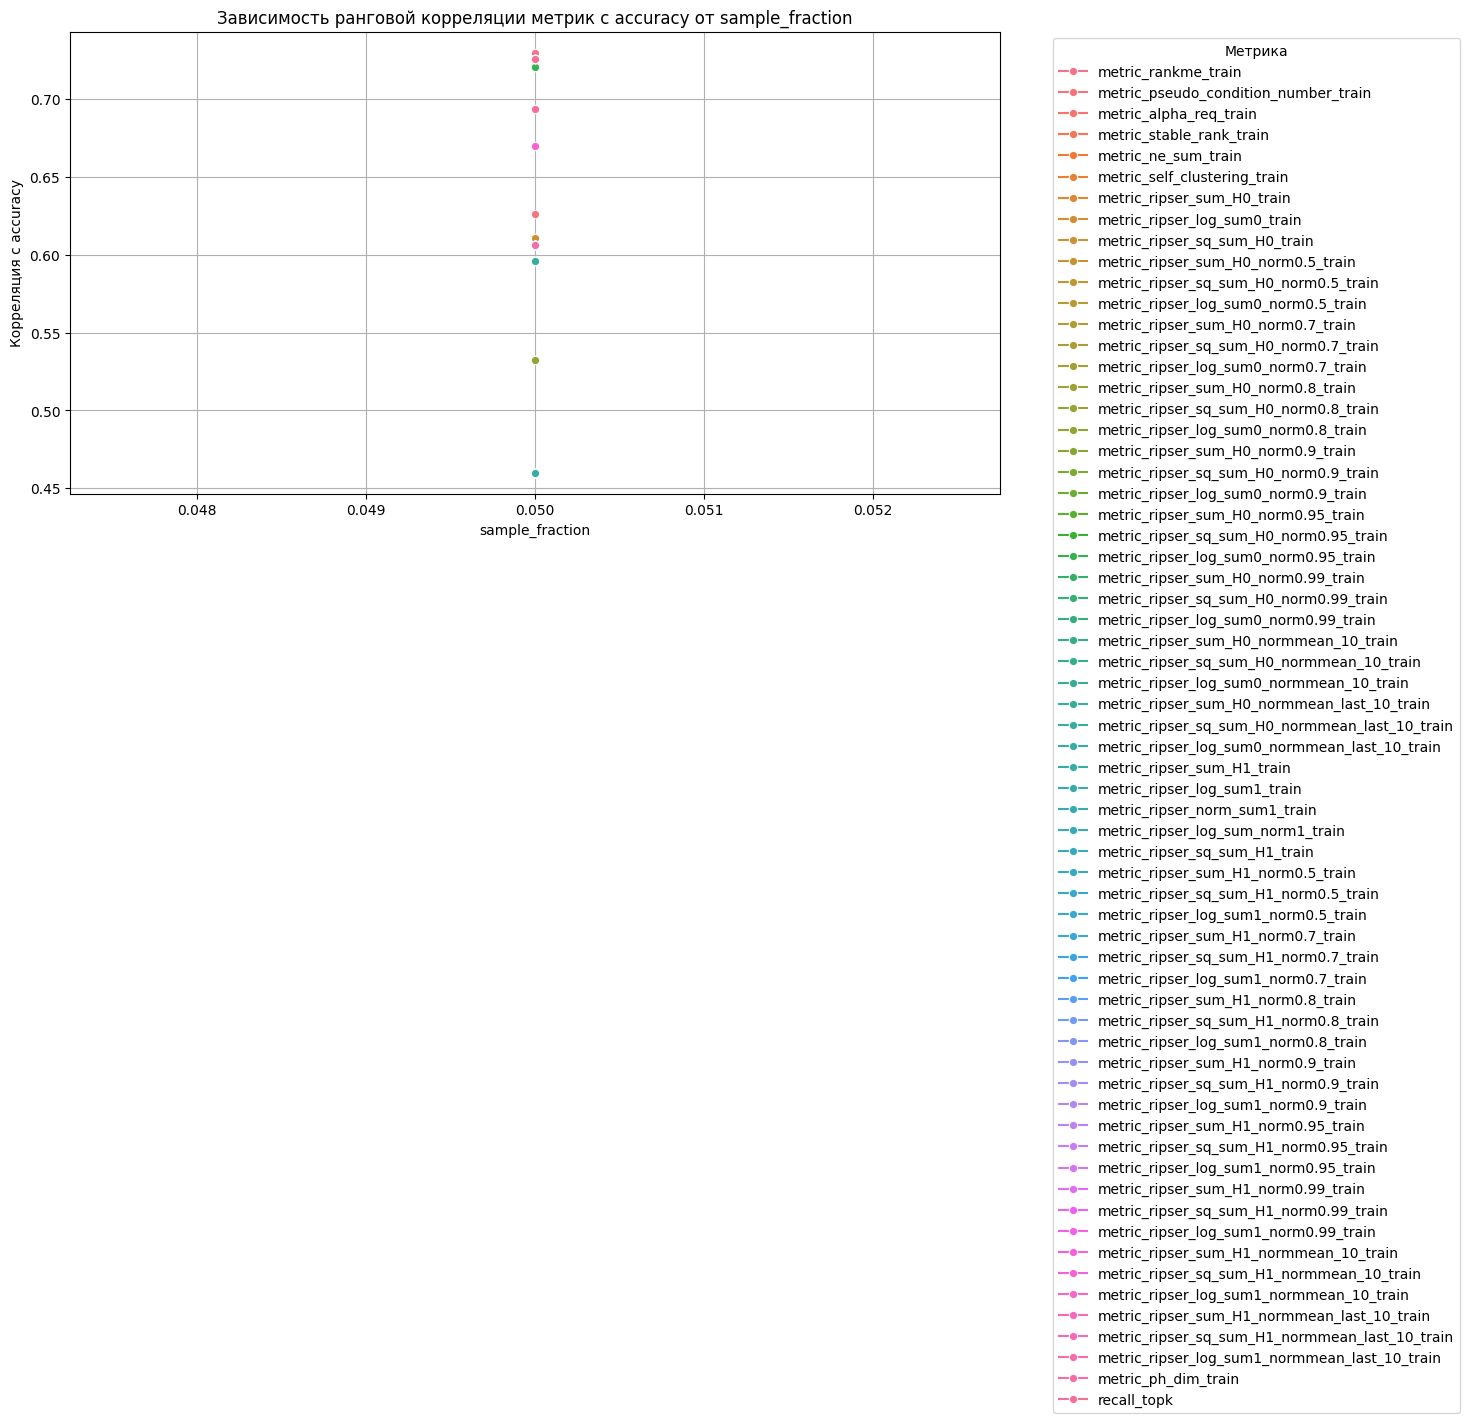

loss


/tmp/ipykernel_1470740/3567089855.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


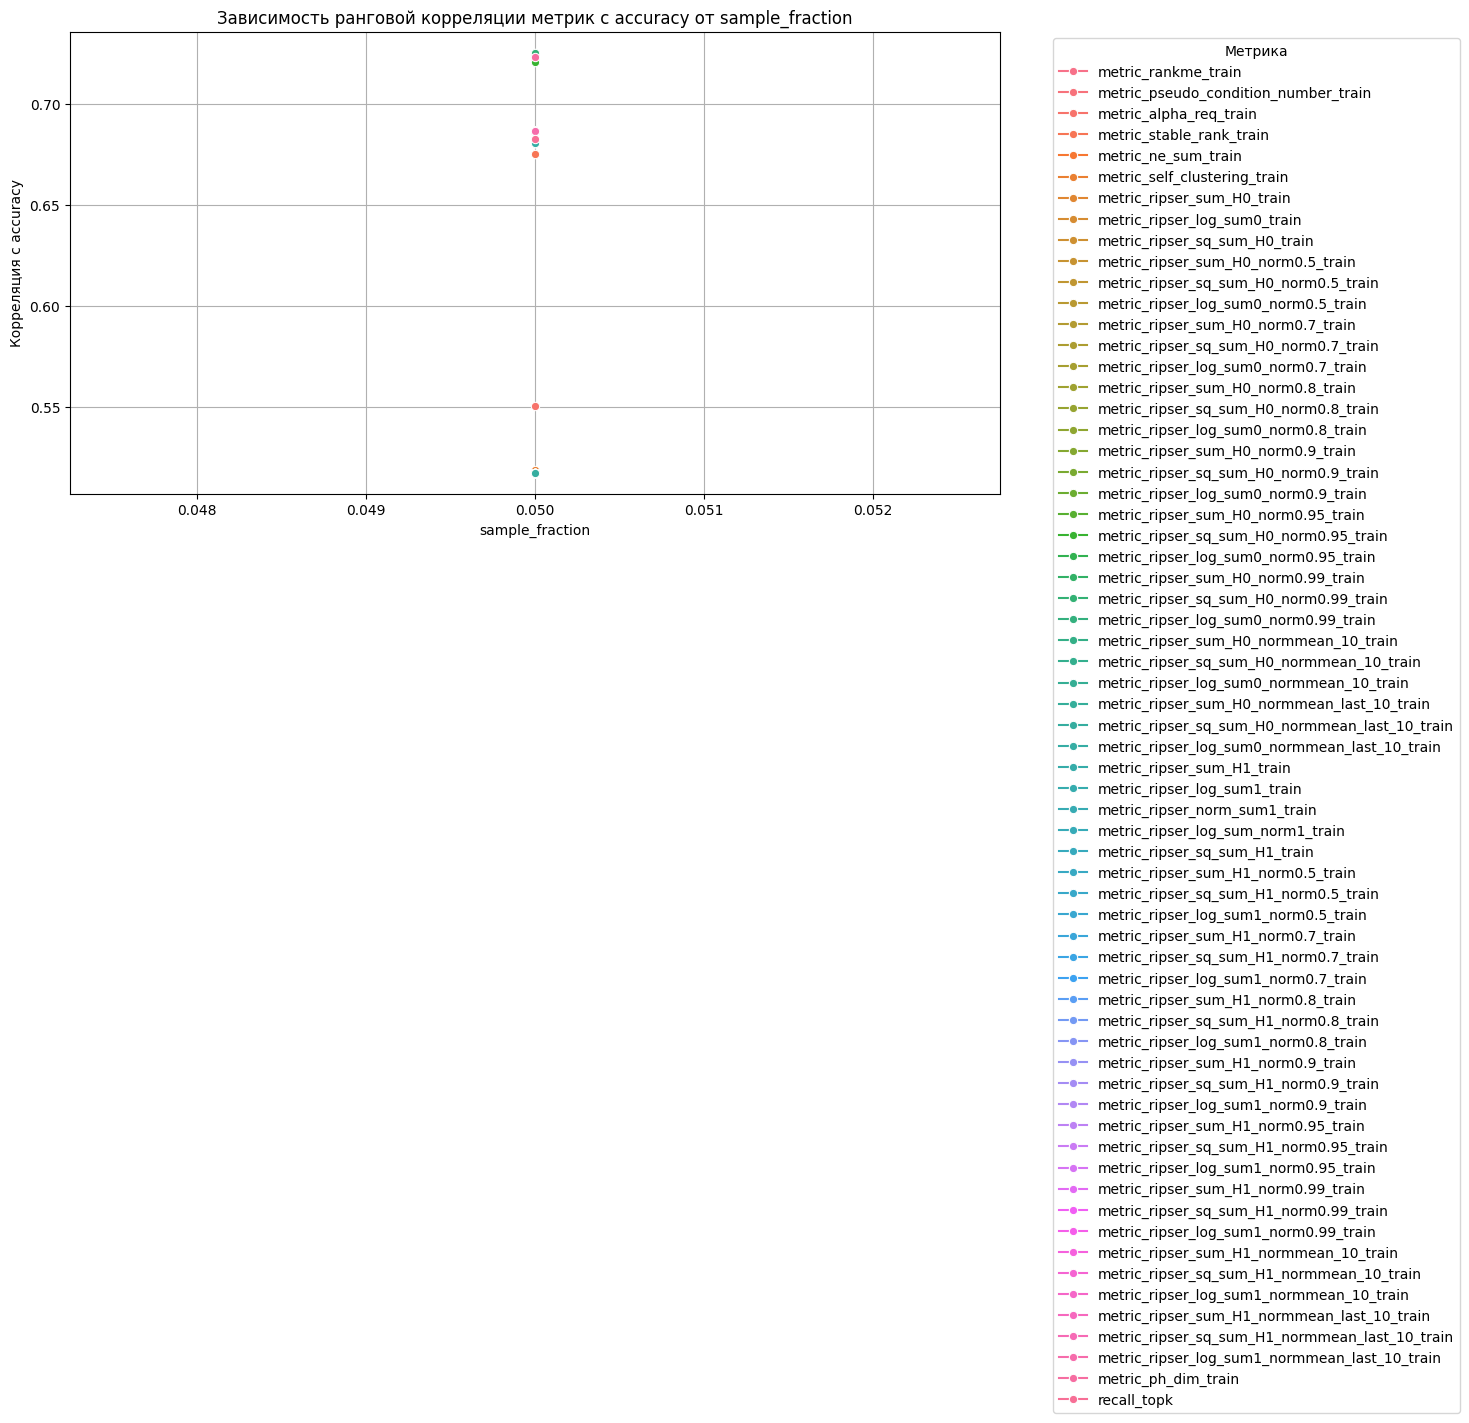

rnn_encoder_type


/tmp/ipykernel_1470740/3567089855.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


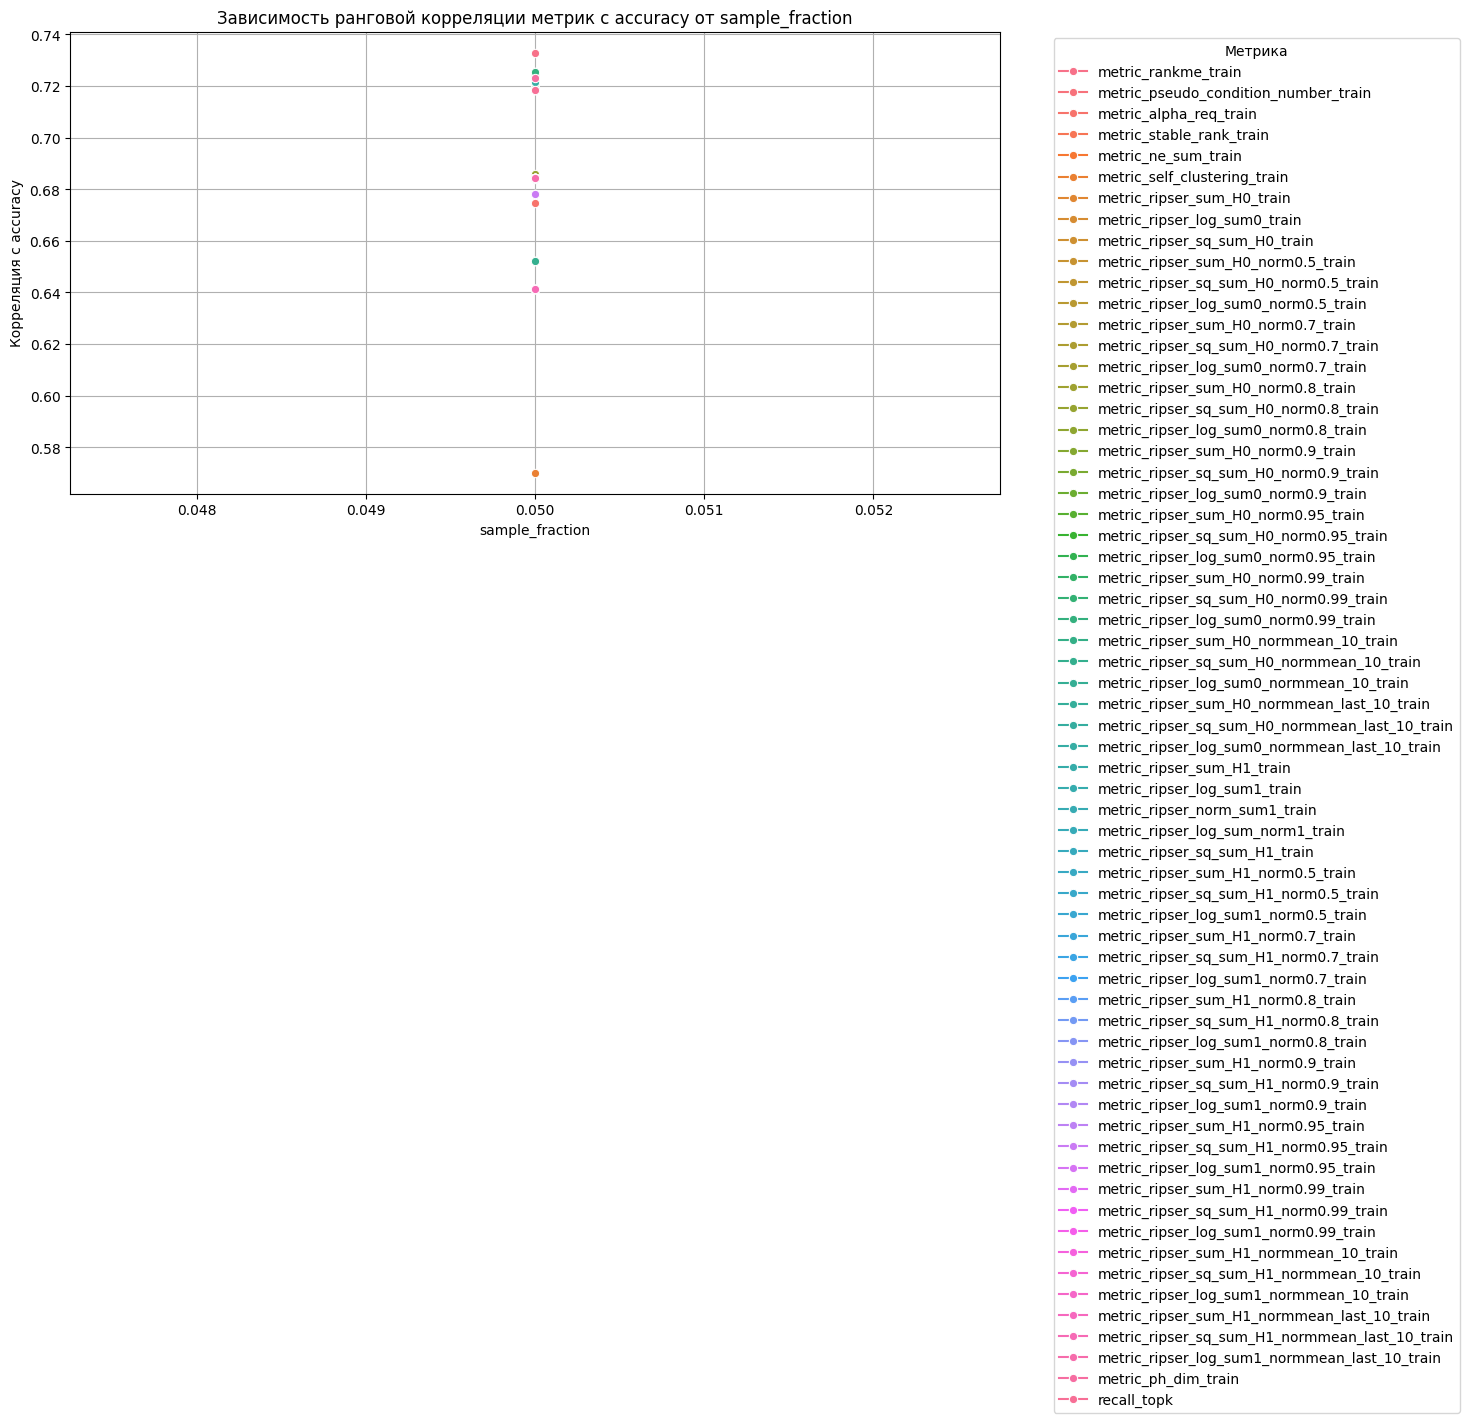

In [79]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    print(param)
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=corr_df, x="sample_fraction", y="auc", hue="metric", marker="o")
    plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
    plt.xlabel("sample_fraction")
    plt.ylabel("Корреляция с accuracy")
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
    plt.tight_layout()
    plt.show()
    

In [80]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    mean_corr = corr_df[corr_df['sample_fraction'] < 0.5].groupby("metric")["auc"].mean().sort_values(ascending=False)
    print(param)
    print(mean_corr)

batch_size
metric
recall_topk                                       0.7673
metric_self_clustering_train                      0.7577
metric_ripser_sq_sum_H1_norm0.8_train             0.7546
metric_ripser_sq_sum_H1_norm0.95_train            0.7546
metric_ripser_sq_sum_H1_norm0.5_train             0.7546
                                                   ...  
metric_ripser_sq_sum_H0_norm0.8_train             0.5633
metric_ripser_sum_H0_norm0.7_train                0.5633
metric_ripser_sum_H0_norm0.5_train                0.5633
metric_ripser_sq_sum_H0_normmean_last_10_train    0.5633
metric_stable_rank_train                          0.5633
Name: auc, Length: 64, dtype: float64
learning_rate
metric
recall_topk                                       0.7536
metric_ne_sum_train                               0.7507
metric_rankme_train                               0.7465
metric_ripser_sq_sum_H0_norm0.99_train            0.7286
metric_ripser_sum_H0_norm0.99_train               0.7286
           

In [ ]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["auc"].mean().sort_values(ascending=False)
    print(param)
    print(mean_corr)

In [ ]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["auc"].mean().sort_values(ascending=False)
    print(param)
    print(mean_corr)

In [ ]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["auc"].mean().sort_values(ascending=False)
    print(param)
    print(mean_corr)

# Standard deviation of score of best param selection

In [ ]:
std_corr = {}
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    std_corr[param] = corr_df.groupby("metric")["auc"].std().sort_values()

In [ ]:
for param in params_cols:
    sorted_std = std_corr[param].sort_values(ascending=True)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
    
    for i, v in enumerate(sorted_std.values):
        plt.text(v, i, f"{v:.6f}", color='black', ha='left', va='center', fontsize=9)
    print(param)
    plt.title("📉 Стандартное отклонение корреляции метрик (стабильность)")
    plt.xlabel("Стандартное отклонение")
    plt.tight_layout()
    plt.show()